#### __`Importing Libraries, Setting Display Options`__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))     # To view numerical values in dataframe columns uniformly
pd.set_option('display.max_columns', None)                              # To view all columns in .describe() 

#### __`Data Loading`__

In [2]:
df = pd.read_excel('premiums_young_with_gr.xlsx')
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,4


#### __`Data Cleaning`__

##### Features : Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    20096 non-null  int64 
 1   Gender                 20096 non-null  object
 2   Region                 20096 non-null  object
 3   Marital_status         20096 non-null  object
 4   Number Of Dependants   20096 non-null  int64 
 5   BMI_Category           20096 non-null  object
 6   Smoking_Status         20094 non-null  object
 7   Employment_Status      20095 non-null  object
 8   Income_Level           20092 non-null  object
 9   Income_Lakhs           20096 non-null  int64 
 10  Medical History        20096 non-null  object
 11  Insurance_Plan         20096 non-null  object
 12  Annual_Premium_Amount  20096 non-null  int64 
 13  Genetical_Risk         20096 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.1+ MB


* `Target is 'int', as expected`
* `Let's move to Features`

In [4]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [5]:
df.dtypes

age                       int64
gender                   object
region                   object
marital_status           object
number_of_dependants      int64
bmi_category             object
smoking_status           object
employment_status        object
income_level             object
income_lakhs              int64
medical_history          object
insurance_plan           object
annual_premium_amount     int64
genetical_risk            int64
dtype: object

In [6]:
df.dtypes.unique()

array([dtype('int64'), dtype('O')], dtype=object)

In [7]:
temp = pd.DataFrame(df.drop(columns=['annual_premium_amount']).dtypes).reset_index()
temp.columns = ['feature_name','feature_type']

num_features = list(temp[temp['feature_type'].astype(str).isin(['int64'])]['feature_name'])
cat_features = list(temp[temp['feature_type'].astype(str).isin(['object'])]['feature_name'])

print(f'Total Features       : {df.shape[1]-1}', '\n')

print(f'Numerical Features   : {len(num_features)}   ', num_features)
print(f'Categorical Features : {len(cat_features)}   ', cat_features)

Total Features       : 13 

Numerical Features   : 4    ['age', 'number_of_dependants', 'income_lakhs', 'genetical_risk']
Categorical Features : 9    ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']


##### NaN Values

In [8]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
379,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191,3
6853,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001,2
7634,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,NaN,NaN,8,No Disease,Bronze,5873,2
7757,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010,5
9813,18,Male,Southwest,Married,3,Normal,Occasional,Freelancer,NaN,6,No Disease,Silver,8484,1
15037,19,Male,Southeast,Unmarried,0,Overweight,Occasional,Salaried,NaN,3,No Disease,Silver,9174,1


* `Dropping Rows with NaN as the count is too low`

In [10]:
df = df.dropna().reset_index(drop=True)
print(df.isnull().sum())
print('\n SHAPE : ', df.shape)

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

 SHAPE :  (20090, 14)


##### Checking for Duplicates

In [11]:
# There's no Primary Key, so checking with .dupicated().sum()

df.duplicated().sum()

0

##### Checking Numerical Columns for inconsistencies

In [12]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.00,20090.00,20090.00,20090.00,20090.00
mean,21.49,0.72,22.51,8142.10,2.50
std,2.29,0.94,23.42,2749.91,1.71
min,18.00,-3.00,1.00,3501.00,0.00
25%,19.00,0.00,6.00,6022.25,1.00
50%,22.00,0.00,16.00,7939.00,3.00
75%,23.00,1.00,31.00,9561.00,4.00
max,25.00,3.00,790.00,18186.00,5.00


`number_of_dependants`

In [13]:
# number_of_dependants can't be negative

In [14]:
df['number_of_dependants'].value_counts()

number_of_dependants
 0    10856
 1     5467
 2     2231
 3     1514
-3       12
-1       10
Name: count, dtype: int64

In [15]:
df['number_of_dependants'] = np.abs(df['number_of_dependants'])             # can also do   abs(df['number_of_dependants'])

In [16]:
df['number_of_dependants'].value_counts()

number_of_dependants
0    10856
1     5477
2     2231
3     1526
Name: count, dtype: int64

`income_lakhs`

In [17]:
# Let's check for Outliers since 75th percentile is a lot smaller than max

<Axes: xlabel='income_lakhs', ylabel='Count'>

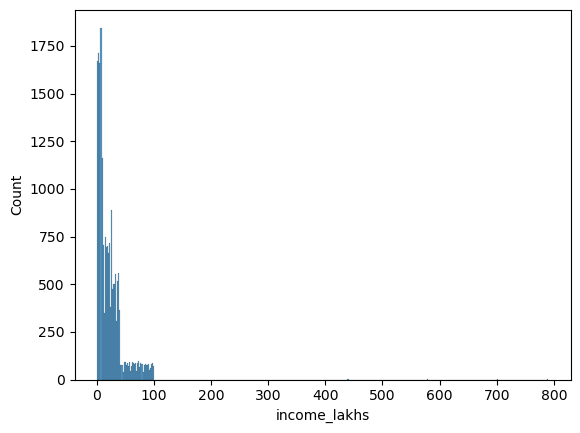

In [18]:
sns.histplot(df['income_lakhs'])

<Axes: xlabel='income_lakhs', ylabel='Count'>

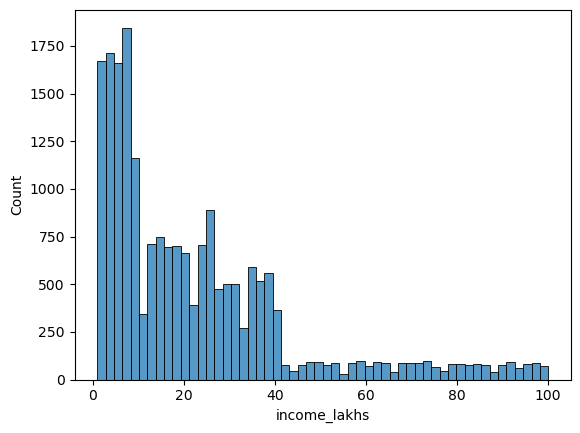

In [19]:
sns.histplot(df[df['income_lakhs']<150]['income_lakhs'])

In [20]:
df[df['income_lakhs']>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1676,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636,3
4310,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888,5
4660,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424,3
6250,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586,0


In [21]:
# Since they're all outliers, let's drop income above 100 Lakhs

In [22]:
df = df[df['income_lakhs']<=100].reset_index(drop=True)

In [23]:
df.shape

(20086, 14)

`genetical_risk`

<Axes: xlabel='genetical_risk', ylabel='Count'>

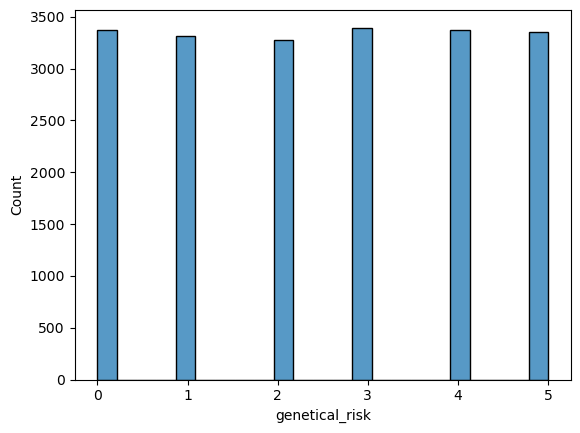

In [24]:
sns.histplot(df['genetical_risk'])

##### Checking Categorical Columns for inconsistencies

In [25]:
for feature in cat_features:
    print(df[feature].value_counts(), '\n')

gender
Male      11055
Female     9031
Name: count, dtype: int64 

region
Southeast    6969
Southwest    6118
Northwest    4043
Northeast    2956
Name: count, dtype: int64 

marital_status
Unmarried    18075
Married       2011
Name: count, dtype: int64 

bmi_category
Normal         11599
Underweight     4469
Overweight      2742
Obesity         1276
Name: count, dtype: int64 

smoking_status
No Smoking        13850
Regular            4491
Occasional         1735
Smoking=0             5
Does Not Smoke        3
Not Smoking           2
Name: count, dtype: int64 

employment_status
Freelancer       10043
Salaried          7031
Self-Employed     3012
Name: count, dtype: int64 

income_level
<10L         7721
10L - 25L    5662
25L - 40L    4199
> 40L        2504
Name: count, dtype: int64 

medical_history
No Disease                             16873
Diabetes                                 889
High blood pressure                      629
Thyroid                                  464
Diabetes 

`smoking_status`

In [26]:
df.loc[~df['smoking_status'].isin(['No Smoking','Occasional','Regular']), 'smoking_status'] = 'No Smoking'

`medical_history`

In [27]:
df.shape

(20086, 14)

In [28]:
df['health_no_disease']     = 0
df['health_diabetes']       = 0
df['health_high_bp']        = 0
df['health_thyroid']        = 0
df['health_heart_disease']  = 0

df.loc[df['medical_history'].str.contains('No Disease'), 'health_no_disease'] = 1
df.loc[df['medical_history'].str.contains('Diabetes'), 'health_diabetes'] = 1
df.loc[df['medical_history'].str.contains('High blood pressure'), 'health_high_bp'] = 1
df.loc[df['medical_history'].str.contains('Thyroid'), 'health_thyroid'] = 1
df.loc[df['medical_history'].str.contains('Heart disease'), 'health_heart_disease'] = 1

new_added_columns = ['health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease']

In [29]:
df.drop(columns = ['medical_history'], inplace=True)

In [30]:
print(len(cat_features), ' Categorical Features \n', cat_features)

9  Categorical Features 
 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']


In [31]:
cat_features += new_added_columns
cat_features.remove('medical_history')

print(len(cat_features), ' Categorical Features \n', cat_features)

13  Categorical Features 
 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan', 'health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease']


In [32]:
df.shape

(20086, 18)

In [33]:
for i in new_added_columns:
    print(df[i].value_counts(), '\n')

health_no_disease
1    16873
0     3213
Name: count, dtype: int64 

health_diabetes
0    18456
1     1630
Name: count, dtype: int64 

health_high_bp
0    18841
1     1245
Name: count, dtype: int64 

health_thyroid
0    19388
1      698
Name: count, dtype: int64 

health_heart_disease
0    19442
1      644
Name: count, dtype: int64 



#### __`Feature Engineering : Feature Creation`__

In [34]:
# INPUT FROM BUSINESS
# -----------------------------------
#   Risk scores for health conditions
#       No Disease      :   0
#       Diabetes        :   6
#       High BP         :   6
#       Thyroid         :   5
#       Heart Disease   :   8
# -----------------------------------
#   MIN : 0
#   MAX : 25
# -----------------------------------

In [35]:
# Creating a new combined feature : health_risk_score

df['health_risk_score'] = (6 * df['health_diabetes']) + (6 * df['health_high_bp']) + (5 * df['health_thyroid']) + (8 * df['health_heart_disease'])


# I'm doing the below step to normalise health_risk_score on a scale of 0-25, i.e. (min-max)
# The Train Data might be missing the case of 'health_risk_score = 25' but it's theoretically possible

df['health_risk_score'] = df['health_risk_score'] / 25      
                                                            
df.drop(columns=['health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease'], inplace=True)

In [36]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,health_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,4,0.24
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,Silver,11050,3,0.00
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,Silver,11857,4,0.00
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,Bronze,5684,2,0.00
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,5712,1,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20081,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,Gold,11603,1,0.00
20082,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Gold,14498,2,0.24
20083,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,5,0.00
20084,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,4,0.00


In [37]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'health_risk_score'],
      dtype='object')

In [38]:
num_features = ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score', 'genetical_risk']
cat_features = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']

In [39]:
print(len(num_features), num_features)
print(len(cat_features), cat_features)

5 ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score', 'genetical_risk']
8 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


In [40]:
df['health_risk_score'].describe()

count   20086.00
mean        0.05
std         0.13
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.56
Name: health_risk_score, dtype: float64

In [41]:
df['genetical_risk'].describe()

count   20086.00
mean        2.50
std         1.71
min         0.00
25%         1.00
50%         3.00
75%         4.00
max         5.00
Name: genetical_risk, dtype: float64

#### __`EDA`__

In [42]:
print(len(df.columns), df.columns)
print(len(num_features), num_features)
print(len(cat_features), cat_features)

14 Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'health_risk_score'],
      dtype='object')
5 ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score', 'genetical_risk']
8 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


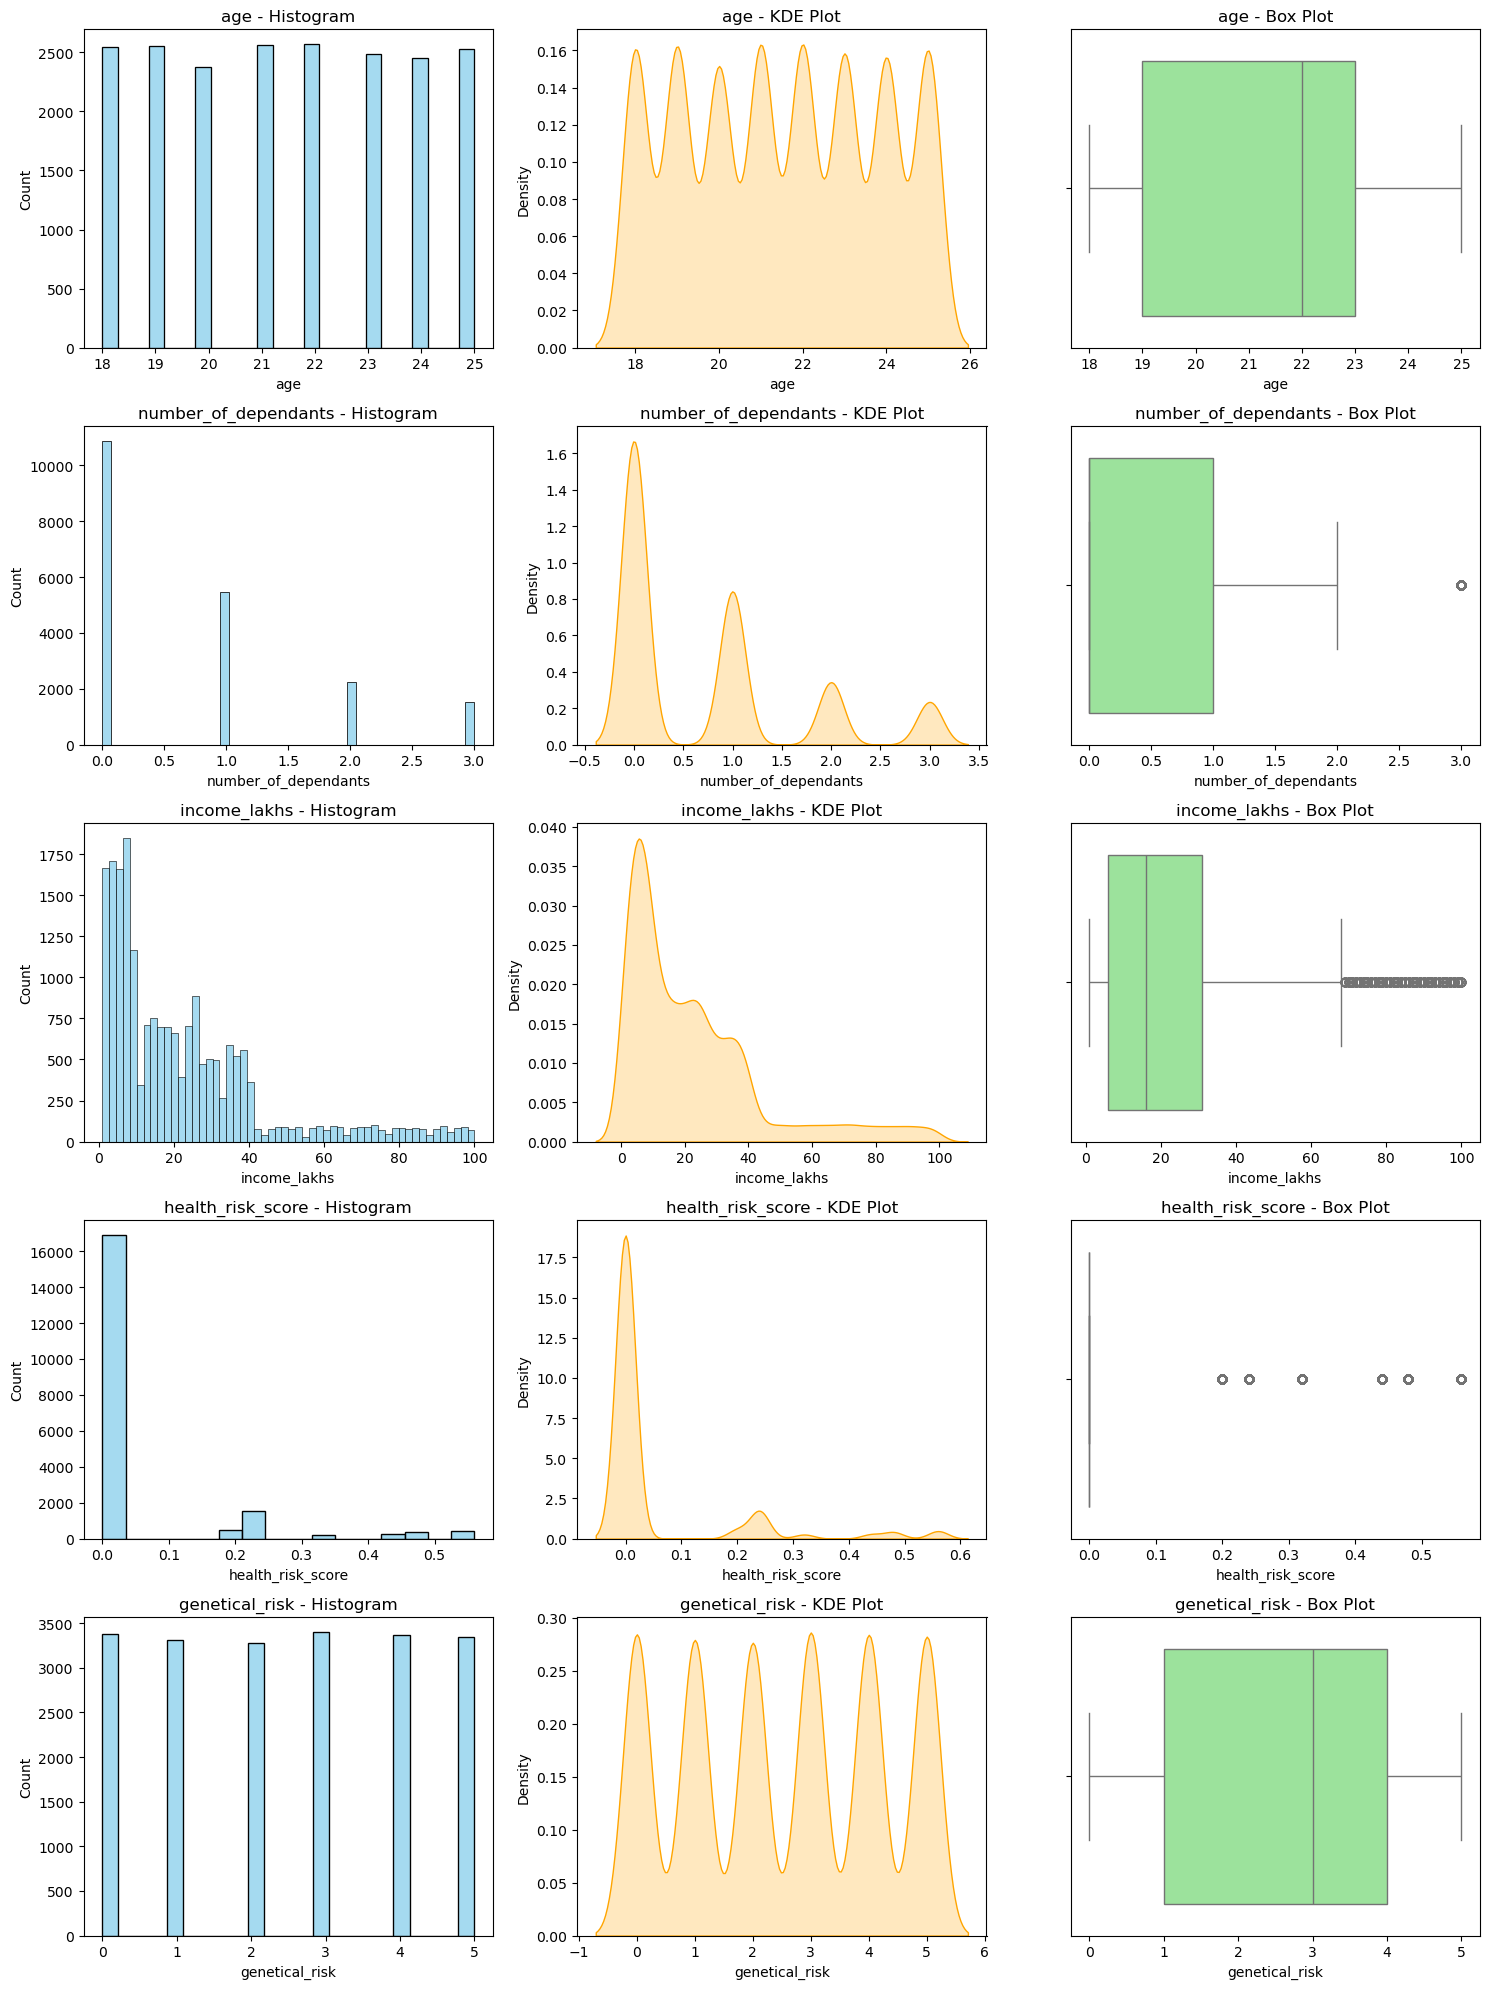

In [43]:
def plot_num_features(df, num_features):
    # Number of features
    n = len(num_features)
    
    # Create a figure with n rows and 3 columns
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(15, 4 * n))

    # If there's only one feature, axes will not be a 2D array, so fix that
    if n == 1:
        axes = axes.reshape(1, 3)

    for i, col in enumerate(num_features):
        # Histogram
        sns.histplot(df[col], ax=axes[i, 0], kde=False, color="skyblue")
        axes[i, 0].set_title(f"{col} - Histogram")

        # KDE plot
        sns.kdeplot(df[col], ax=axes[i, 1], fill=True, color="orange")
        axes[i, 1].set_title(f"{col} - KDE Plot")

        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 2], color="lightgreen")
        axes[i, 2].set_title(f"{col} - Box Plot")

    plt.tight_layout()
    plt.show()
plot_num_features(df, num_features)

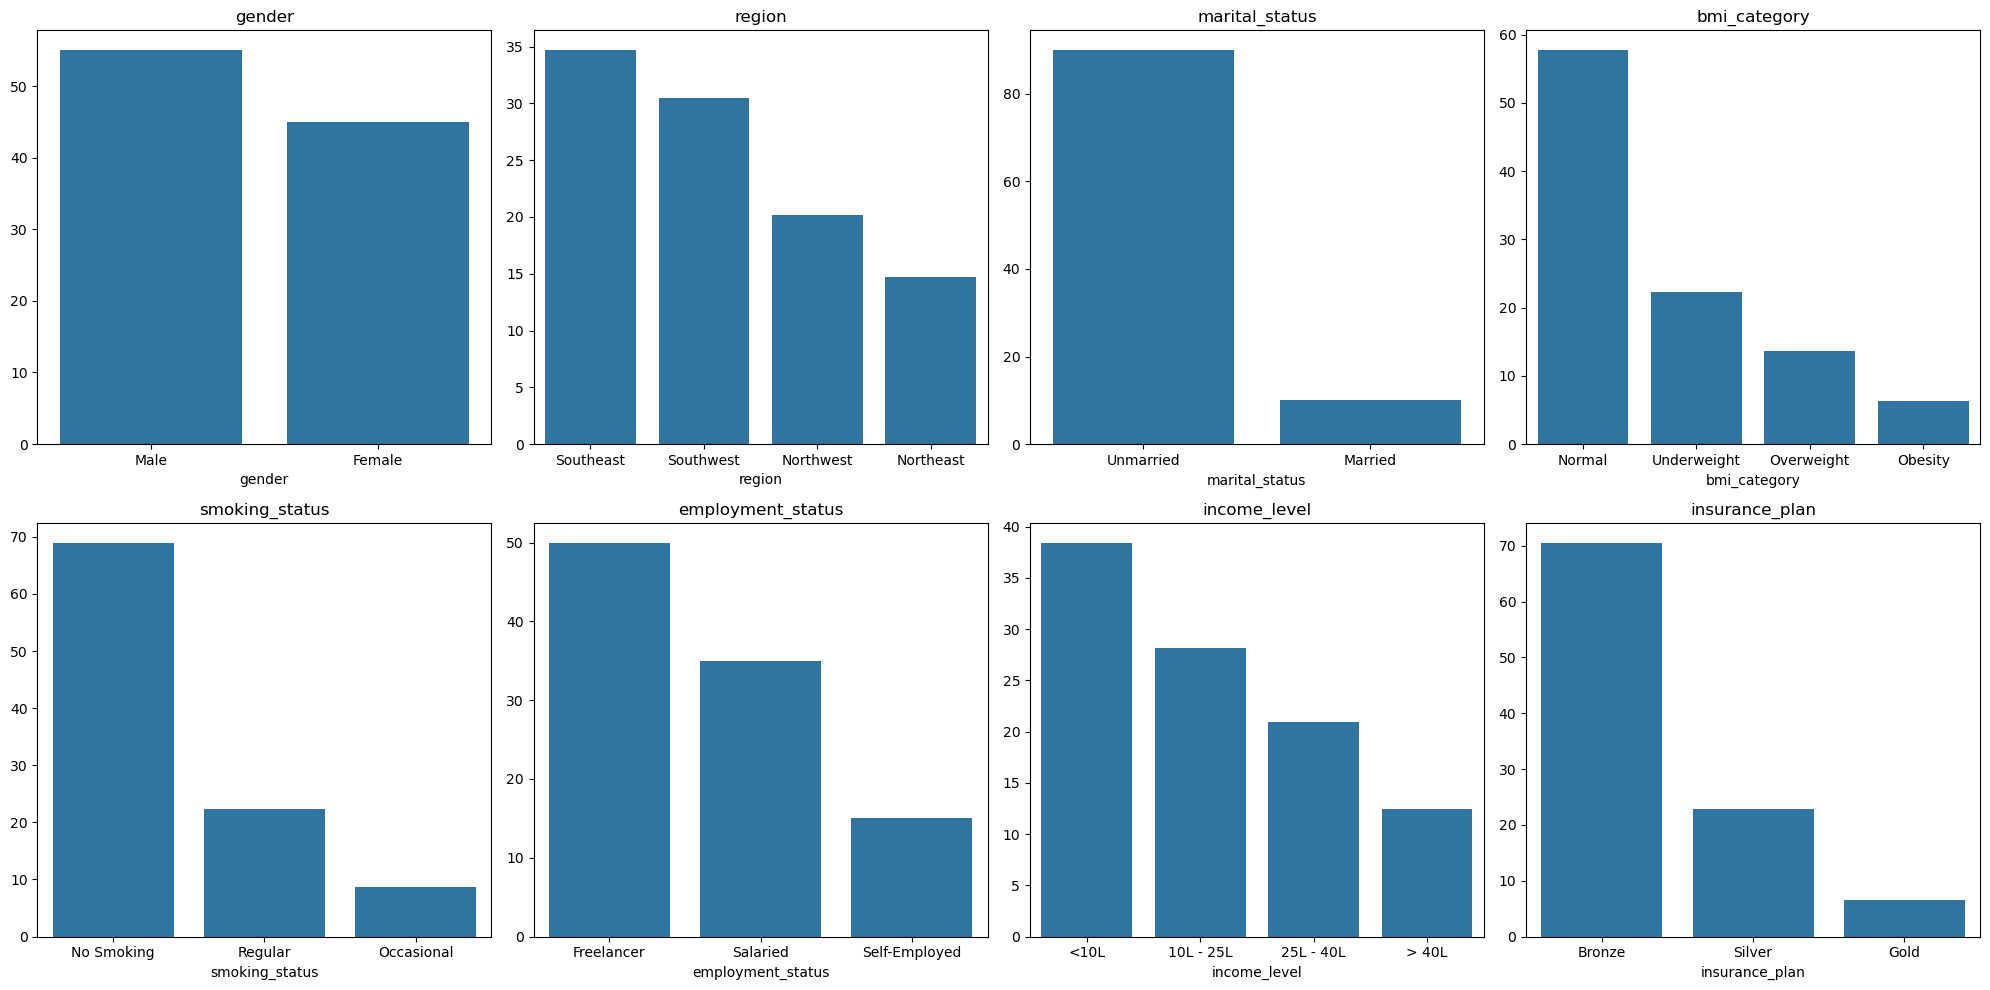

In [44]:
cols = 4                                            # Number of columns per row
n = len(cat_features)
rows = (n // cols) + int(n % cols != 0)
plt.figure(figsize=(cols*5, rows*5))                # Adjust height per row
for i, feature in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    
    percentages = df[feature].value_counts(normalize=True) * 100                # To view percent distribution
    sns.barplot(
        x=percentages.index,
        y=percentages.values
    )
    
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [45]:
df[num_features + ['annual_premium_amount']].corr()

,age,number_of_dependants,income_lakhs,health_risk_score,genetical_risk,annual_premium_amount
age,1.00,0.00,-0.02,0.00,0.01,-0.01
number_of_dependants,0.00,1.00,-0.01,0.04,-0.01,0.01
income_lakhs,-0.02,-0.01,1.00,-0.01,0.00,0.29
health_risk_score,0.00,0.04,-0.01,1.00,-0.01,0.09
genetical_risk,0.01,-0.01,0.00,-0.01,1.00,0.62
annual_premium_amount,-0.01,0.01,0.29,0.09,0.62,1.00


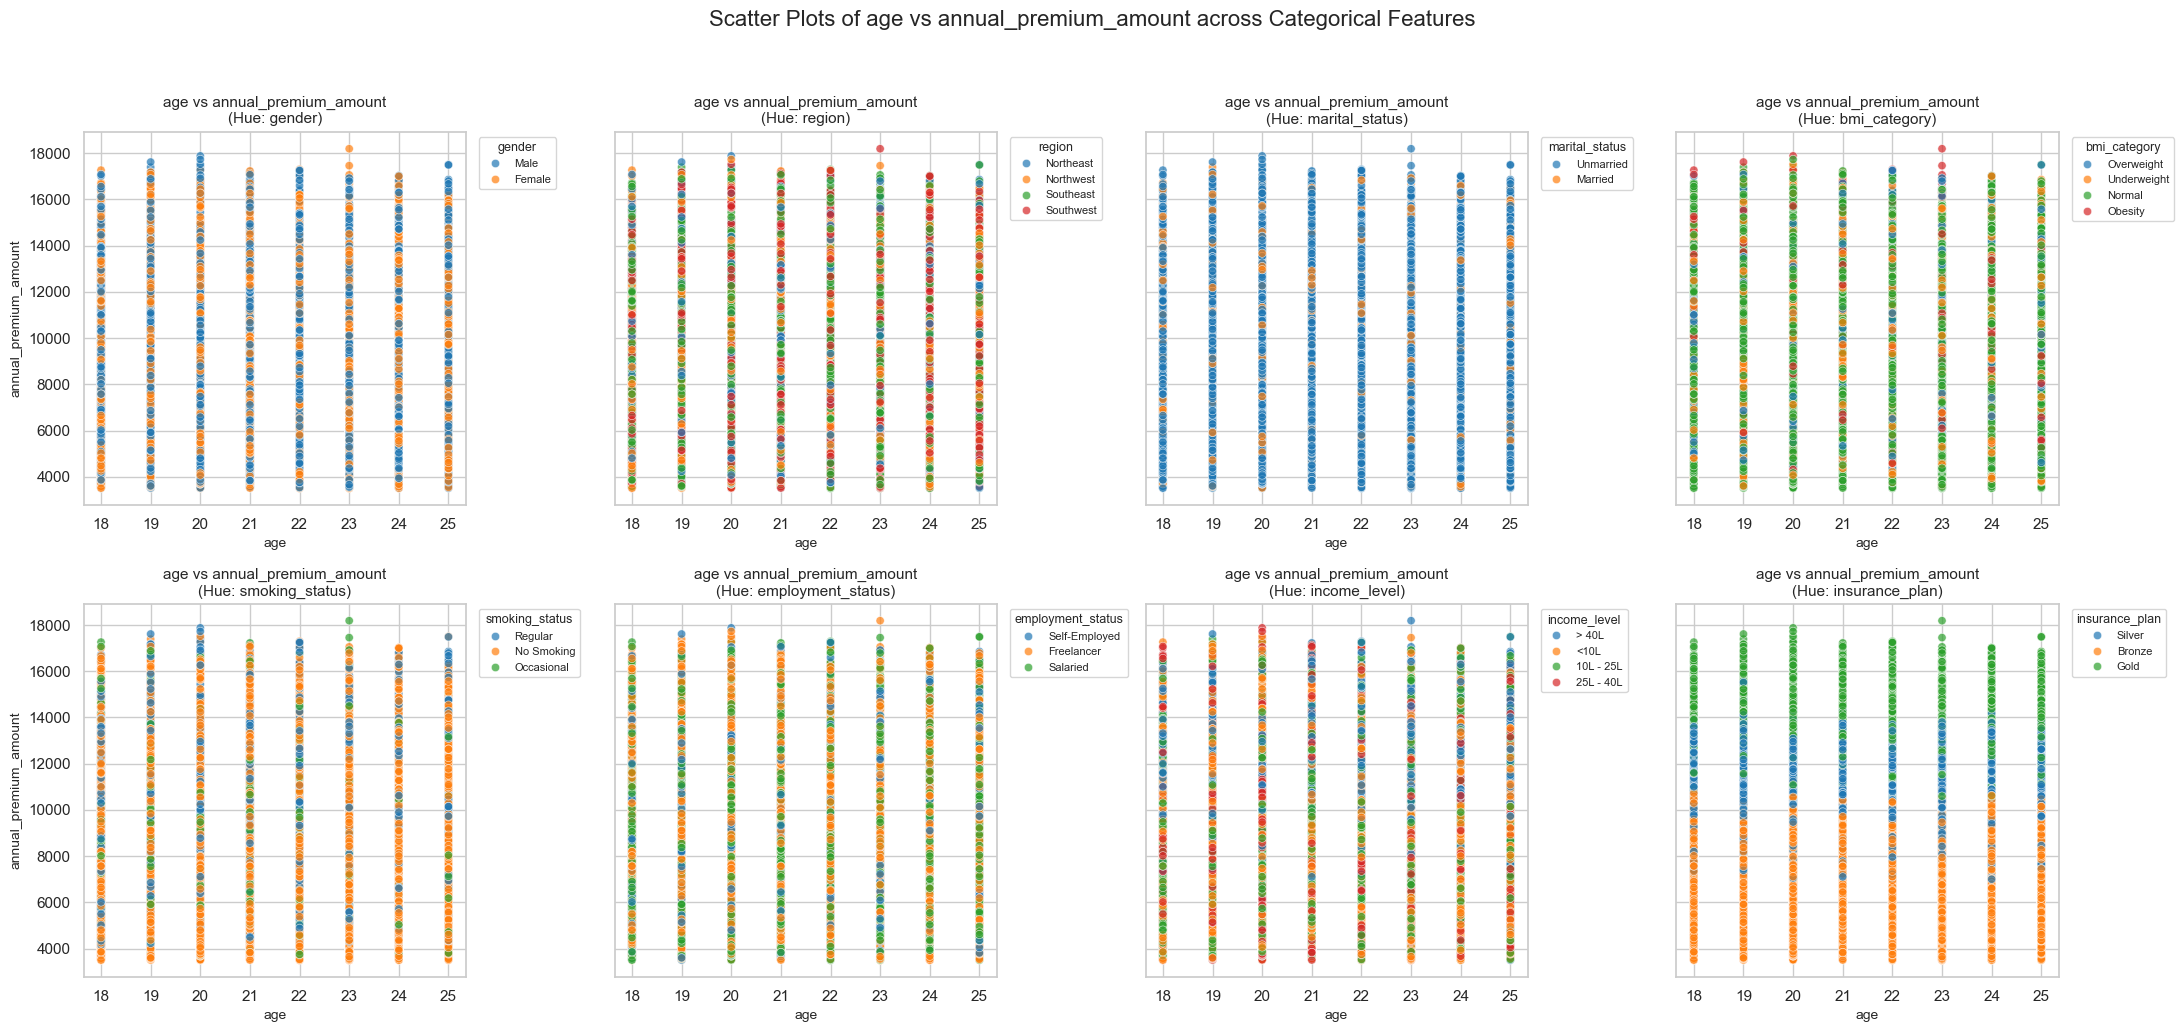

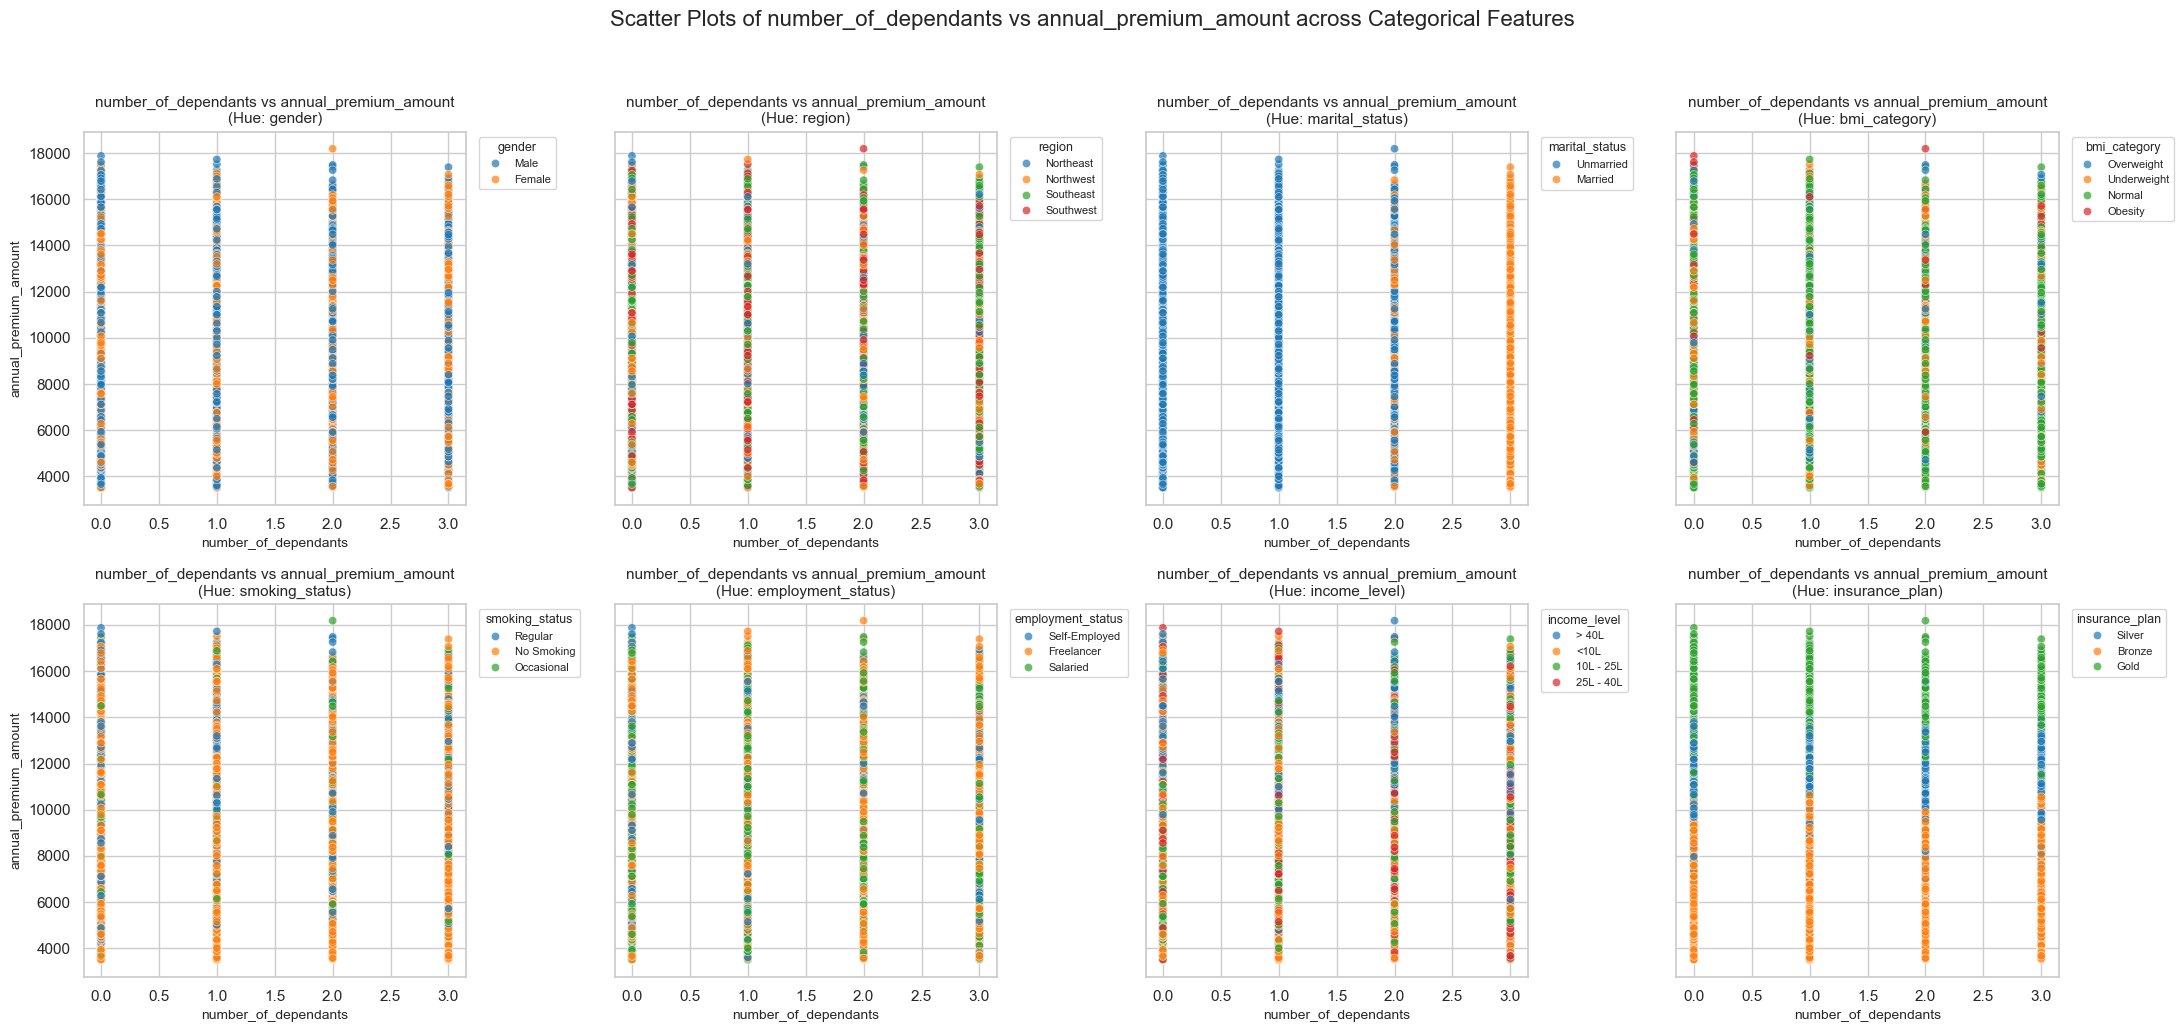

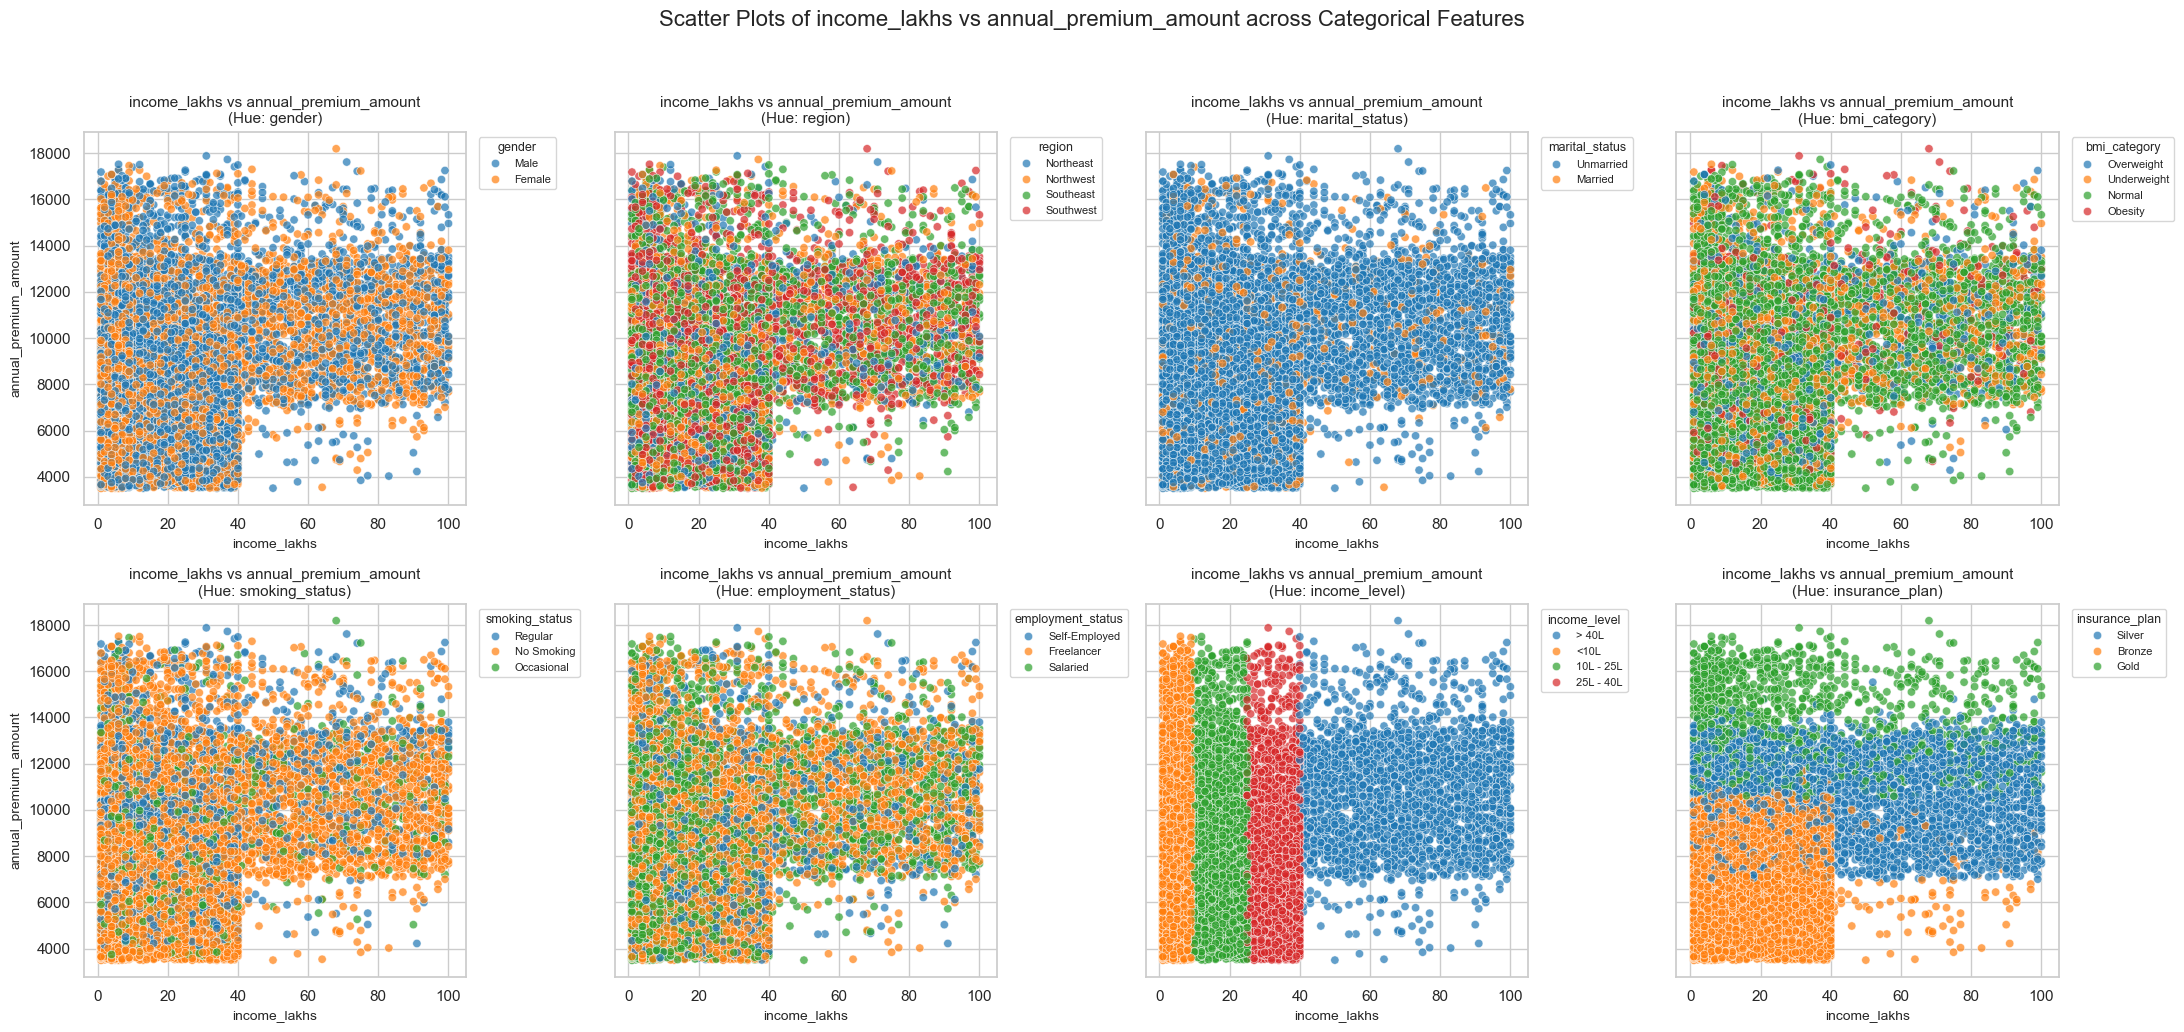

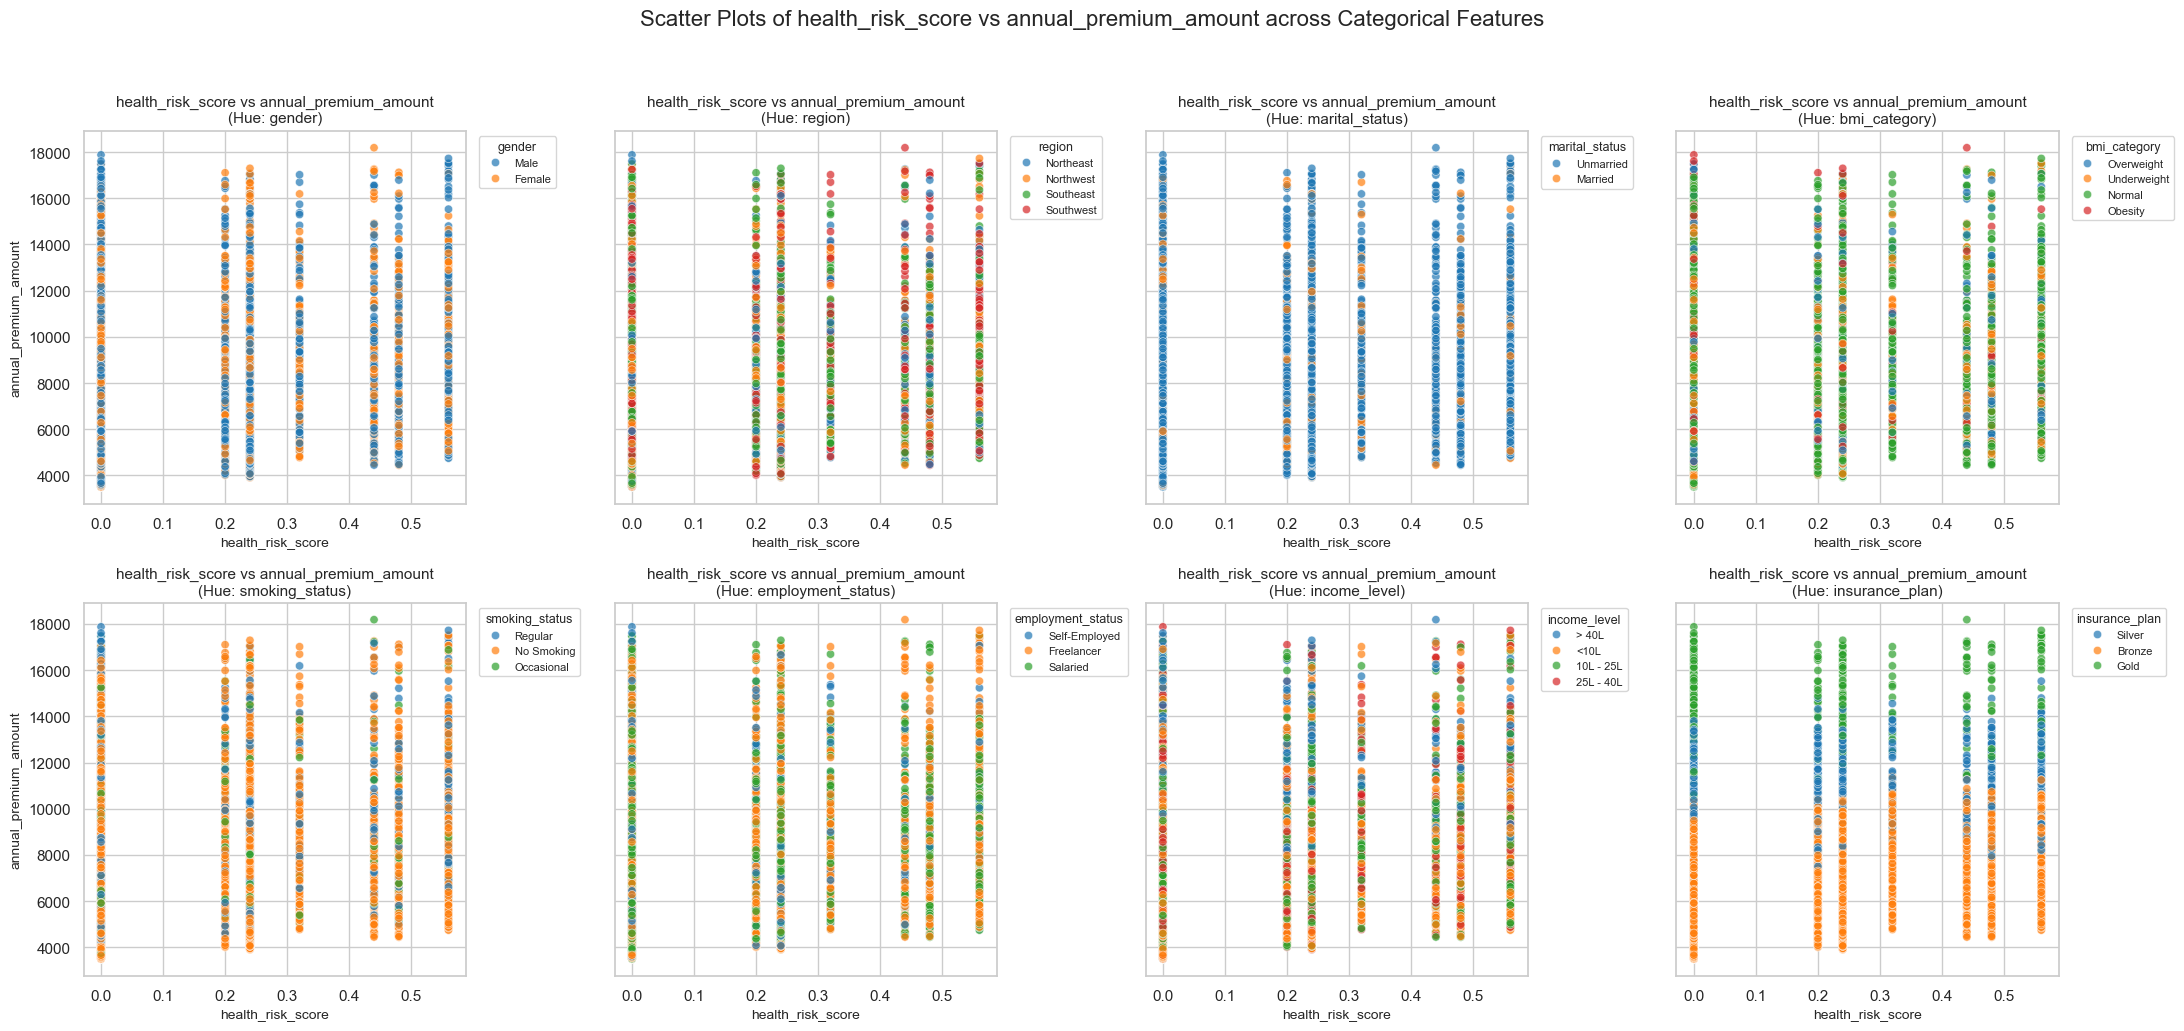

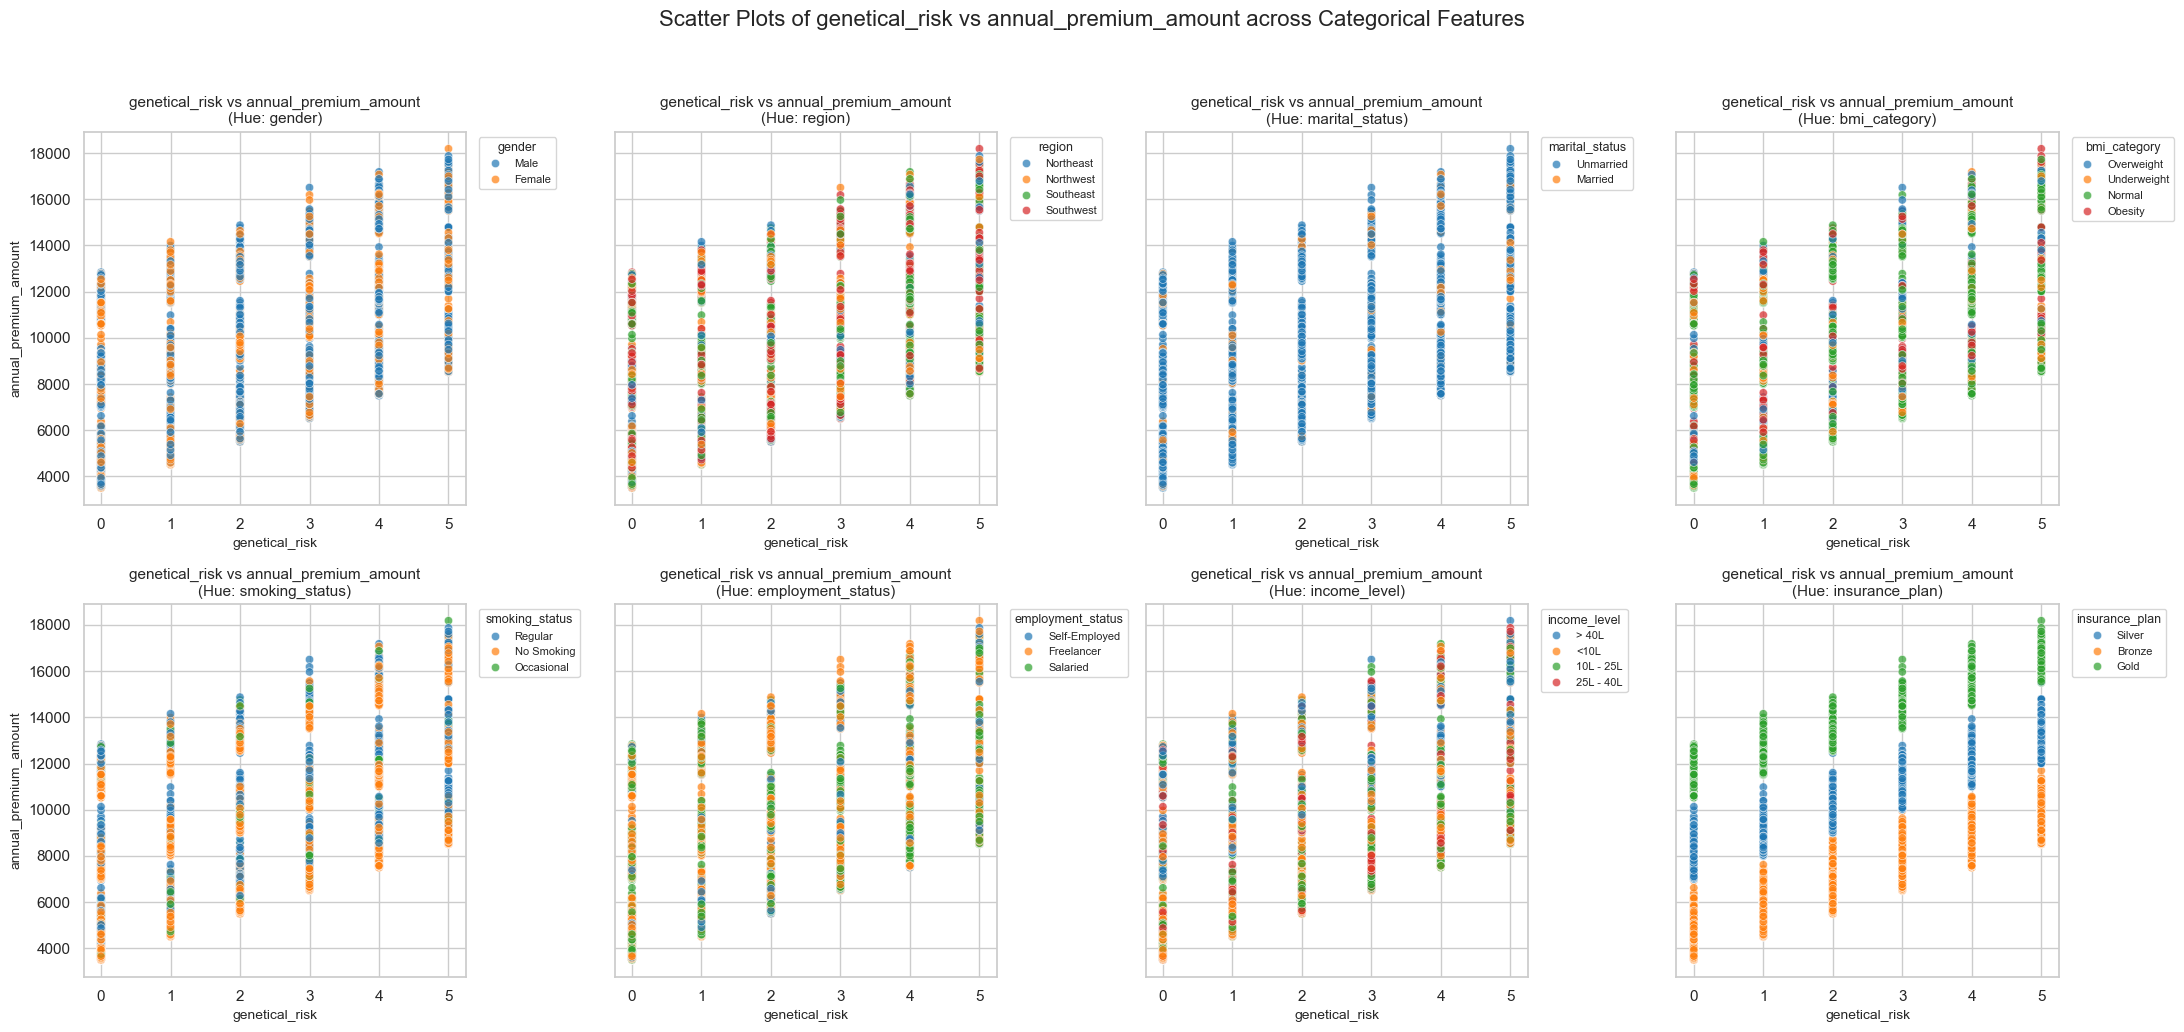

In [46]:
# Set overall plot styling
sns.set_theme(style='whitegrid')

# Loop through each numerical feature
for num_feat in num_features:
  # Create a figure with 2 rows and 4 columns (4 columns total)
  fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10), sharey=True)
  axes = axes.flatten()  # Flatten to easily iterate through axes

  # Loop through each categorical feature and plot on its respective subplot
  for i, cat_feat in enumerate(cat_features):
    sns.scatterplot(
        data=df,
        x=num_feat,
        y='annual_premium_amount',
        hue=cat_feat,
        ax=axes[i],
        alpha=0.7,
        palette='tab10',
    )

    axes[i].set_title(f'{num_feat} vs annual_premium_amount\n(Hue: {cat_feat})', fontsize=11)
    axes[i].set_xlabel(num_feat, fontsize=10)
    axes[i].set_ylabel('annual_premium_amount', fontsize=10)

    # Clean up legends to prevent clutter
    axes[i].legend(
        title=cat_feat,
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8,
        title_fontsize=9,
    )

  # Adjust layout so subplots and legends don't overlap
  plt.suptitle(
      f'Scatter Plots of {num_feat} vs annual_premium_amount across Categorical Features',
      fontsize=16,
      y=1.03,
  )
  plt.tight_layout()
  plt.show()

#### __`Train-Test Split`__

In [47]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,health_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,4,0.24
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,Silver,11050,3,0.00
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,Silver,11857,4,0.00
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,Bronze,5684,2,0.00
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,5712,1,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20081,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,Gold,11603,1,0.00
20082,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Gold,14498,2,0.24
20083,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,5,0.00
20084,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,4,0.00


In [48]:
X, y = df.drop(columns=['annual_premium_amount']), df['annual_premium_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### __`Feature Transformation : Encoding, Scaling`__

In [49]:
print(num_features)
print(cat_features)

['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score', 'genetical_risk']
['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


In [50]:
# -------------------------------------------------------------------------------------------------------------------
# ENCODING
#   One Hot Encoding  :   'gender', 'region', 'marital_status', 'employment_status'
#   Ordinal Encoding  :   'bmi_category', 'smoking_status', 'income_level', 'insurance_plan'
# -------------------------------------------------------------------------------------------------------------------
# SCALING
#   No Scaling      :   OHE features ['gender', 'region', 'marital_status', 'employment_status']
#                   :   'health_risk_score' is already normalised
#   StandardScaler  :   Ordinal Encoded Features ['bmi_category', 'smoking_status', 'income_level', 'insurance_plan']
#                   :   ( num_features - ['health_risk_score'] ), i.e., ['age', 'number_of_dependants', 'income_lakhs', 'genetical_risk']
# -------------------------------------------------------------------------------------------------------------------

In [51]:
nominal_features = ['gender', 'region', 'marital_status', 'employment_status']
ordinal_features = ['bmi_category', 'smoking_status', 'income_level', 'insurance_plan']

In [52]:
for feature in ordinal_features:
    print(df[feature].unique())

['Overweight' 'Underweight' 'Normal' 'Obesity']
['Regular' 'No Smoking' 'Occasional']
['> 40L' '<10L' '10L - 25L' '25L - 40L']
['Silver' 'Bronze' 'Gold']


In [53]:
ordinal_categories = [
    ['Underweight', 'Normal', 'Overweight', 'Obesity'],
    ['No Smoking', 'Occasional', 'Regular'],
    ['<10L', '10L - 25L', '25L - 40L', '> 40L'],
    ['Bronze', 'Silver', 'Gold']
]

In [54]:
feature_engg = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_features),
    ('numerical', StandardScaler(), num_features),
    ('ordinal', Pipeline(steps=[
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale', StandardScaler())]), ordinal_features)   
], remainder='passthrough', verbose_feature_names_out=False)        

#   remainder='passthrough' is very important
#   verbose_feature_names_out=False removes ugly prefixes

In [55]:
X_train_transformed = pd.DataFrame(feature_engg.fit_transform(X_train), columns=feature_engg.get_feature_names_out())

#### __`Feature Selection`__

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [57]:
calculate_vif(X_train_transformed)

,Column,VIF
0,gender_Male,2.24
1,region_Northwest,2.06
2,region_Southeast,2.77
3,region_Southwest,2.56
4,marital_status_Unmarried,6.84
5,employment_status_Salaried,1.66
6,employment_status_Self-Employed,1.29
7,age,1.00
8,number_of_dependants,1.36
9,income_lakhs,6.10


In [58]:
calculate_vif(X_train_transformed.drop(columns=['income_level']))

,Column,VIF
0,gender_Male,2.23
1,region_Northwest,2.06
2,region_Southeast,2.77
3,region_Southwest,2.56
4,marital_status_Unmarried,6.83
5,employment_status_Salaried,1.66
6,employment_status_Self-Employed,1.29
7,age,1.00
8,number_of_dependants,1.36
9,income_lakhs,1.19


- I'll let marital_status_Unmarried stay because it captures a completely unique piece of information
- I'll drop income_level because they're essentially the same data

#### __`Data Pre-Processing Pipeline`__

In [59]:
num_features = ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score', 'genetical_risk']
cat_features = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'insurance_plan']

nominal_features = ['gender', 'region', 'marital_status', 'employment_status']
ordinal_features = ['bmi_category', 'smoking_status', 'insurance_plan']

ordinal_categories = [
    ['Underweight', 'Normal', 'Overweight', 'Obesity'],
    ['No Smoking', 'Occasional', 'Regular'],
    ['Bronze', 'Silver', 'Gold']
]

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_features),
    ('numerical', StandardScaler(), num_features),
    ('ordinal', Pipeline(steps=[
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale', StandardScaler())]), ordinal_features)   
    ],
    remainder='drop',
    verbose_feature_names_out=False)

#### __`Model Training & Evaluation`__

In [60]:
def evaluate_model(model_name, X_train, X_test, y_train, y_test):
    
    # Train set Evaluation
    y_pred_train = model_name.predict(X_train)

    print('PERFORMANCE WITH TRAIN SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_train, y_pred_train):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_train, y_pred_train):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_train, y_pred_train):.4f}")

    # Test set Evaluation
    y_pred_test = model_name.predict(X_test)

    print('\n\nPERFORMANCE WITH TEST SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_test, y_pred_test):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_test, y_pred_test):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_test, y_pred_test):.4f}")

---

##### Model 1 : Linear Regression

In [61]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('linear_regressor', LinearRegression())
])

model_1.fit(X_train, y_train)
evaluate_model(model_1, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  276.47
MSE        :  110,054.40
RMSE       :  331.74
R2 Score   :  0.9854


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  278.98
MSE        :  111,263.00
RMSE       :  333.56
R2 Score   :  0.9854


In [62]:
print('COEFFICIENTS : \n------------------------------------------')
print(pd.Series(model_1.named_steps['linear_regressor'].coef_, index=model_1.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

COEFFICIENTS : 
------------------------------------------
insurance_plan                    2091.64
genetical_risk                    1705.63
health_risk_score                  257.13
smoking_status                     247.54
bmi_category                       164.33
employment_status_Self-Employed     12.26
employment_status_Salaried           5.91
number_of_dependants                 4.90
marital_status_Unmarried             4.24
region_Southwest                     3.76
age                                  0.44
region_Southeast                     0.29
region_Northwest                    -0.92
income_lakhs                        -0.97
gender_Male                        -15.81
dtype: float64


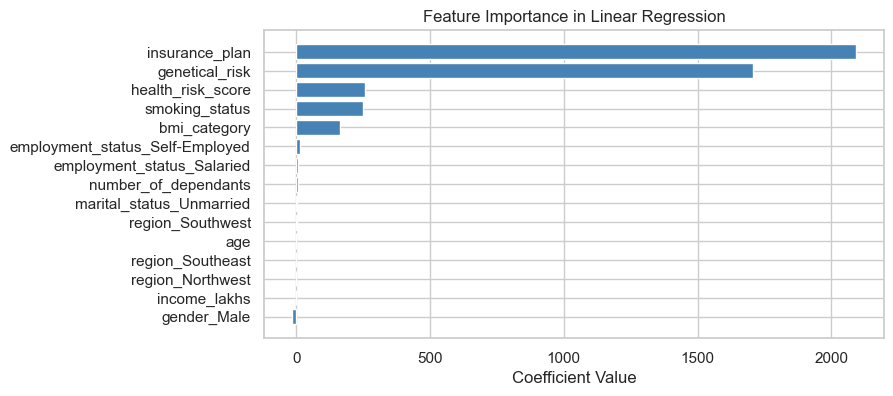

In [64]:
coef_df = pd.DataFrame(
    model_1.named_steps['linear_regressor'].coef_,
    index=model_1.named_steps['preprocessor'].get_feature_names_out(),
    columns=['coefficients']
    ).sort_values(by='coefficients', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.gca().invert_yaxis()
plt.show()

---

##### Model 2 : XGB

In [65]:
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_regressor', XGBRegressor())
])

model_2.fit(X_train, y_train)
evaluate_model(model_2, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  195.98
MSE        :  55,074.12
RMSE       :  234.68
R2 Score   :  0.9927


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  266.36
MSE        :  97,085.62
RMSE       :  311.59
R2 Score   :  0.9873


In [66]:
print('FEATURE IMPORTANCE : \n------------------------------------------')
print(pd.Series(model_2.named_steps['xgb_regressor'].feature_importances_, index=model_2.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

FEATURE IMPORTANCE : 
------------------------------------------
insurance_plan                    0.80
genetical_risk                    0.18
smoking_status                    0.01
health_risk_score                 0.01
bmi_category                      0.00
employment_status_Salaried        0.00
income_lakhs                      0.00
number_of_dependants              0.00
age                               0.00
region_Southeast                  0.00
region_Northwest                  0.00
employment_status_Self-Employed   0.00
region_Southwest                  0.00
marital_status_Unmarried          0.00
gender_Male                       0.00
dtype: float32


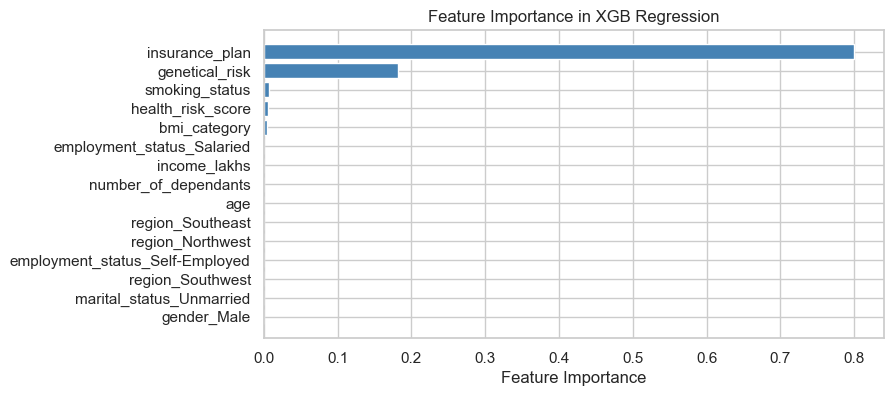

In [67]:
feature_importance_df = pd.DataFrame(
    model_2.named_steps['xgb_regressor'].feature_importances_,
    index=model_2.named_steps['preprocessor'].get_feature_names_out(),
    columns=['feature_importance']
    ).sort_values(by='feature_importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df.index, feature_importance_df['feature_importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in XGB Regression')
plt.gca().invert_yaxis()
plt.show()

---

#### __`Error Analysis`__

In [69]:
y_pred = model_1.predict(X_test)

residuals = y_pred - y_test
residual_pct = (residuals/y_test)*100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residual_pct
})

results_df = results_df.sort_values(by='diff_pct')
results_df

,actual,predicted,diff,diff_pct
3739,4588,3908.52,-679.48,-14.81
10538,4559,3908.77,-650.23,-14.26
2794,4570,3924.71,-645.29,-14.12
12539,5524,4747.52,-776.48,-14.06
6165,4535,3898.88,-636.12,-14.03
...,...,...,...,...
17017,3521,4132.47,611.47,17.37
19809,3512,4126.84,614.84,17.51
12049,3503,4116.97,613.97,17.53
10156,3501,4132.51,631.51,18.04


<Axes: xlabel='diff_pct', ylabel='Count'>

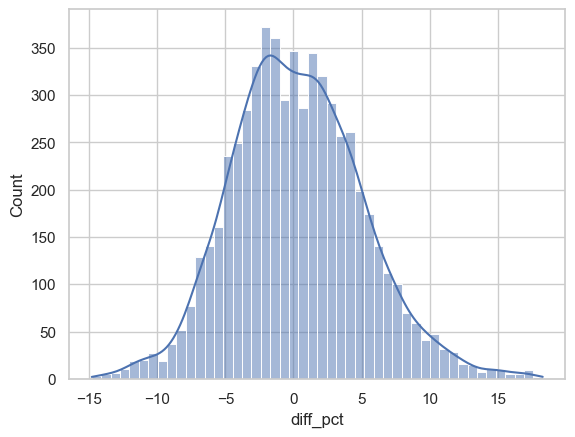

In [70]:
sns.histplot(results_df['diff_pct'], kde=True)

In [71]:
ERROR_THRESHOLD = 10

In [72]:
extreme_results_df = results_df[np.abs(results_df['diff_pct'])>ERROR_THRESHOLD]
extreme_results_df

,actual,predicted,diff,diff_pct
3739,4588,3908.52,-679.48,-14.81
10538,4559,3908.77,-650.23,-14.26
2794,4570,3924.71,-645.29,-14.12
12539,5524,4747.52,-776.48,-14.06
6165,4535,3898.88,-636.12,-14.03
...,...,...,...,...
17017,3521,4132.47,611.47,17.37
19809,3512,4126.84,614.84,17.51
12049,3503,4116.97,613.97,17.53
10156,3501,4132.51,631.51,18.04


In [73]:
print('Percent of Predictions with Extreme Errors : ', (extreme_results_df.shape[0]/results_df.shape[0])*100, '%')

Percent of Predictions with Extreme Errors :  4.6963159641553265 %


In [ ]:
y_pred = model_2.predict(X_test)

residuals = y_pred - y_test
residual_pct = (residuals/y_test)*100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residual_pct
})

results_df = results_df.sort_values(by='diff_pct')
results_df

,actual,predicted,diff,diff_pct
12037,4980,4285.77,-694.23,-13.94
14046,4466,3844.66,-621.34,-13.91
2794,4570,3972.58,-597.42,-13.07
7221,4487,3943.57,-543.43,-12.11
6586,4434,3907.25,-526.75,-11.88
...,...,...,...,...
16611,3609,4170.11,561.11,15.55
19755,3701,4282.38,581.38,15.71
19809,3512,4073.50,561.50,15.99
12049,3503,4078.12,575.12,16.42


<Axes: xlabel='diff_pct', ylabel='Count'>

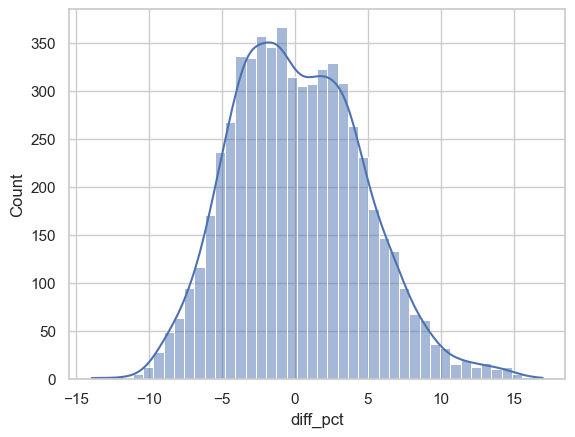

In [ ]:
sns.histplot(results_df['diff_pct'], kde=True)

In [ ]:
extreme_results_df = results_df[np.abs(results_df['diff_pct'])>ERROR_THRESHOLD]
print('Percent of Predictions with Extreme Errors : ', (extreme_results_df.shape[0]/results_df.shape[0])*100, '%')

Percent of Predictions with Extreme Errors :  2.356455360106206 %


##### Analysing the Errors

In [74]:
errors_df = X_test.loc[extreme_results_df.index]
errors_df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,genetical_risk,health_risk_score
3739,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,2,Bronze,0,0.00
10538,20,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,10L - 25L,15,Bronze,0,0.00
2794,21,Female,Southeast,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,29,Bronze,0,0.00
12539,19,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,9,Bronze,0,0.32
6165,25,Male,Northwest,Unmarried,0,Underweight,No Smoking,Salaried,<10L,9,Bronze,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17017,23,Female,Southwest,Unmarried,1,Normal,No Smoking,Salaried,<10L,7,Bronze,0,0.00
19809,18,Female,Northwest,Unmarried,1,Normal,No Smoking,Salaried,<10L,7,Bronze,0,0.00
12049,23,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,25L - 40L,27,Bronze,0,0.00
10156,23,Female,Southwest,Unmarried,1,Normal,No Smoking,Salaried,<10L,6,Bronze,0,0.00


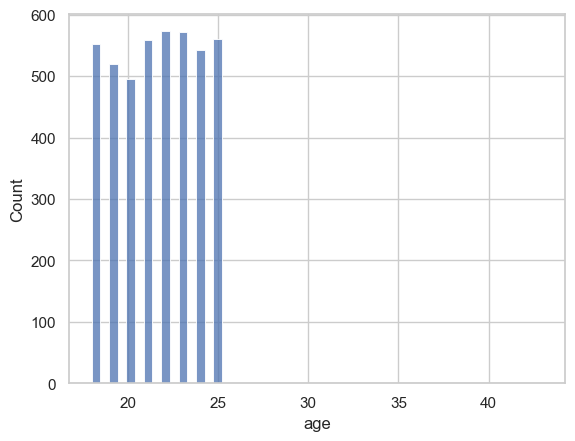

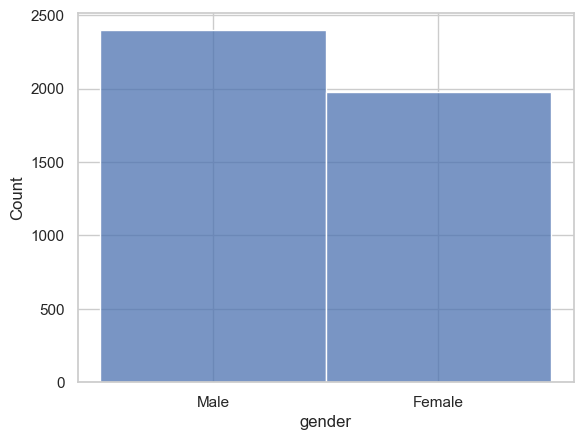

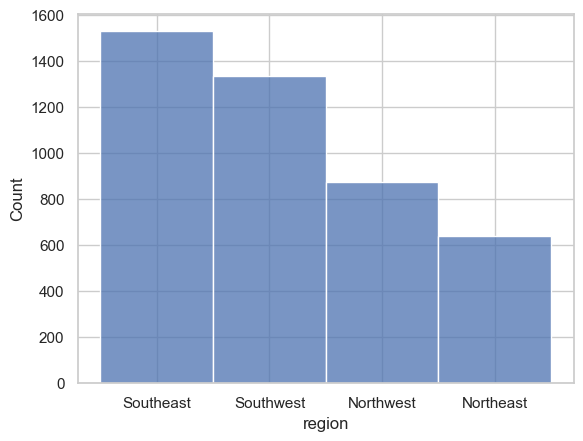

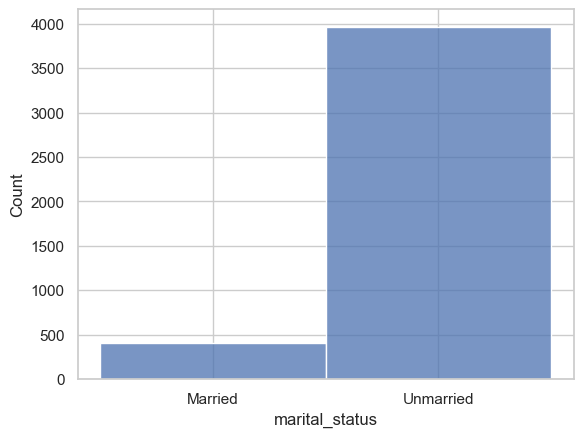

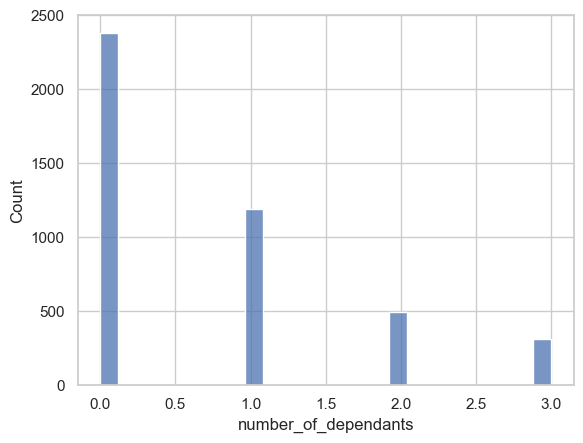

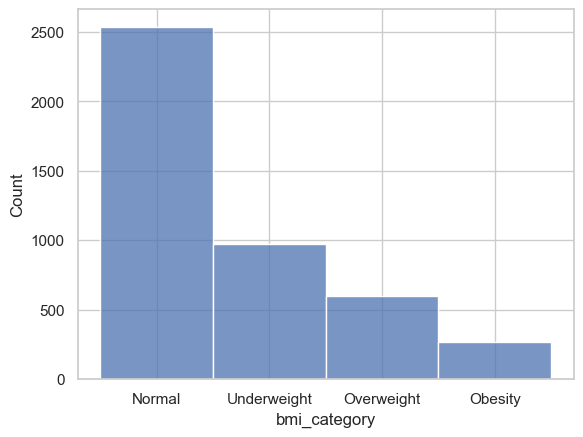

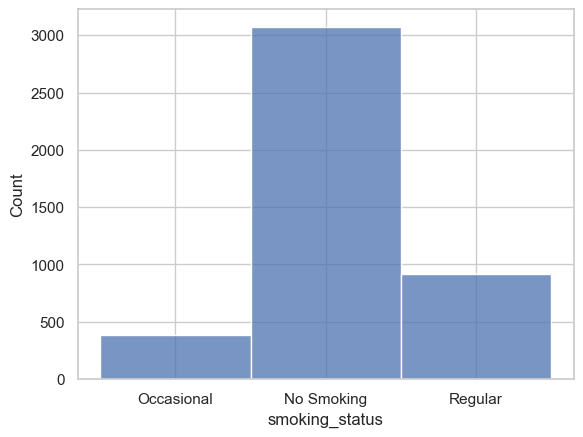

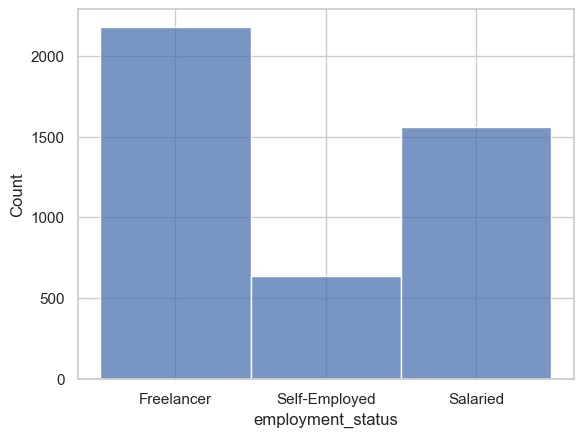

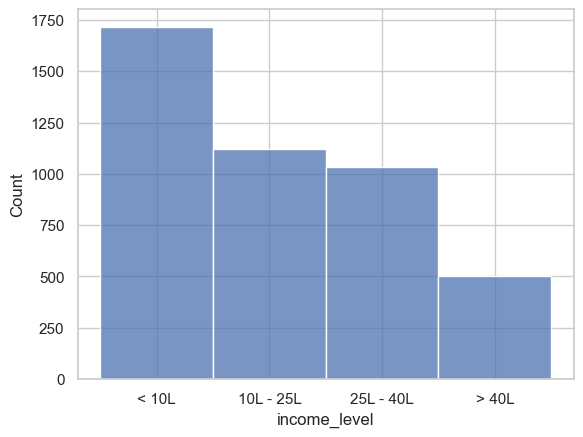

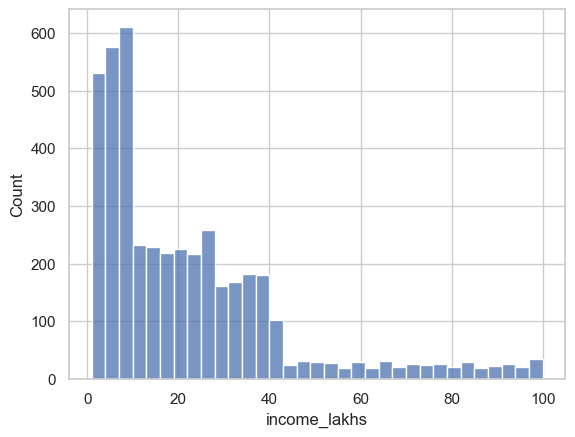

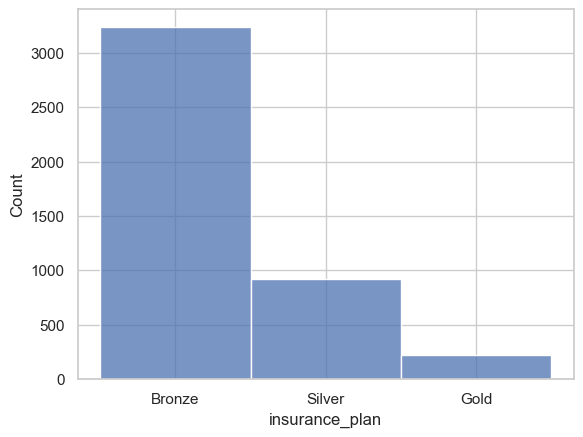

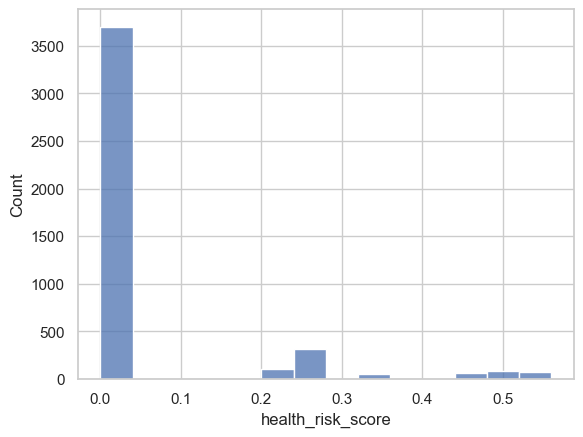

In [258]:
for feature in errors_df.columns:
    sns.histplot(errors_df[feature], label='Overall')
    plt.show()

- `Let's compare distribution of features in Test Set and Extreme Error Set`

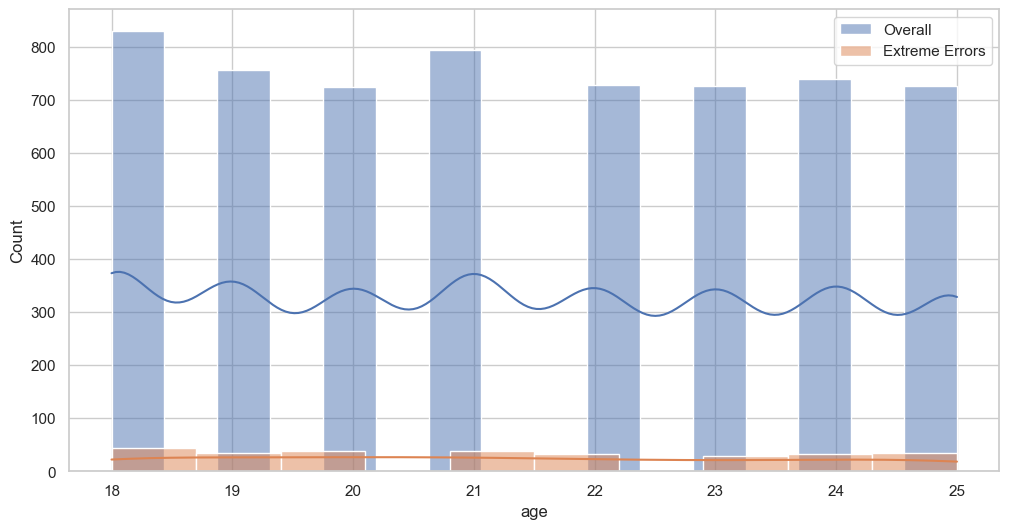

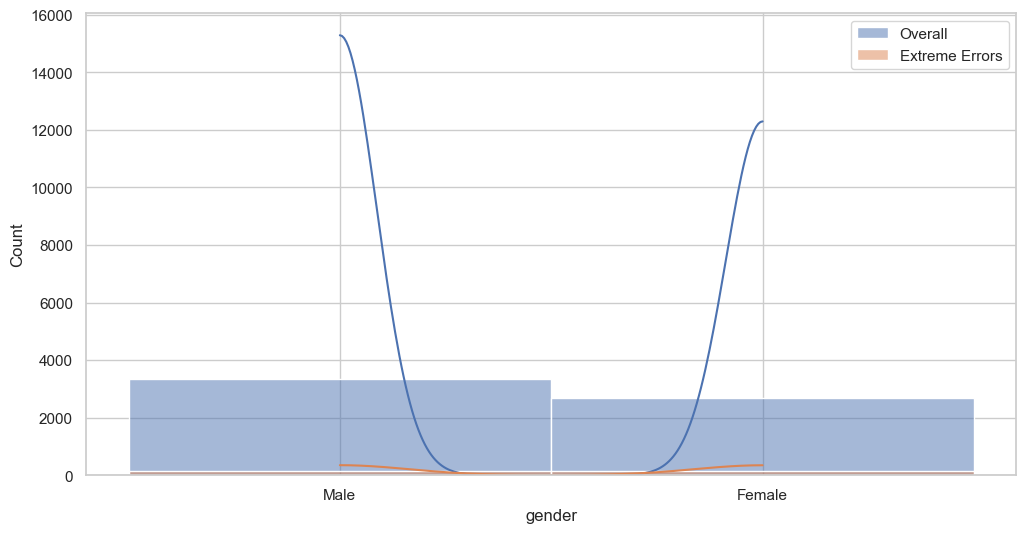

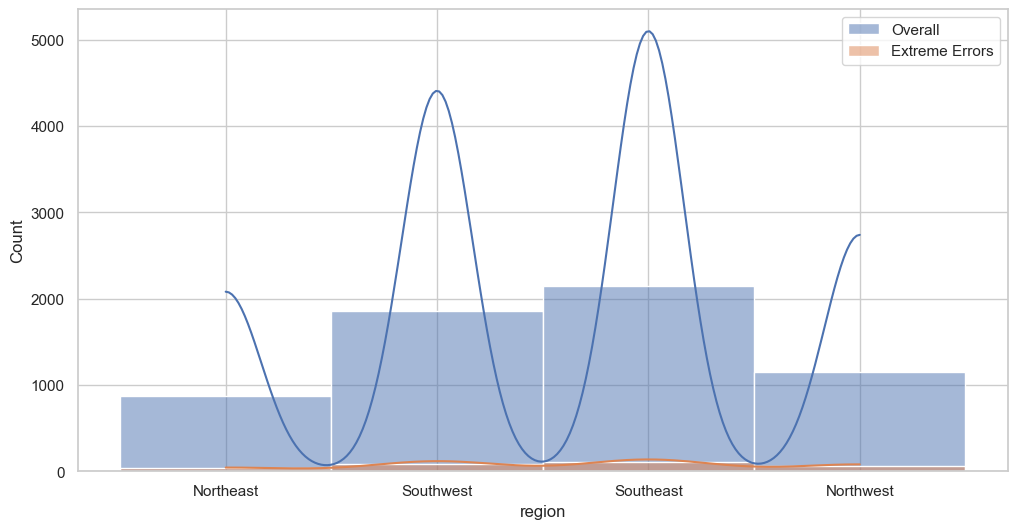

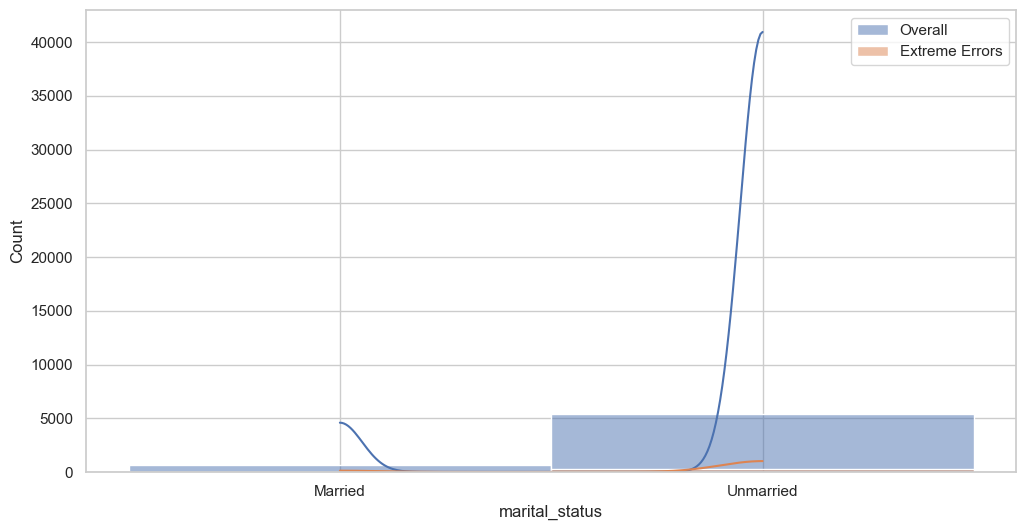

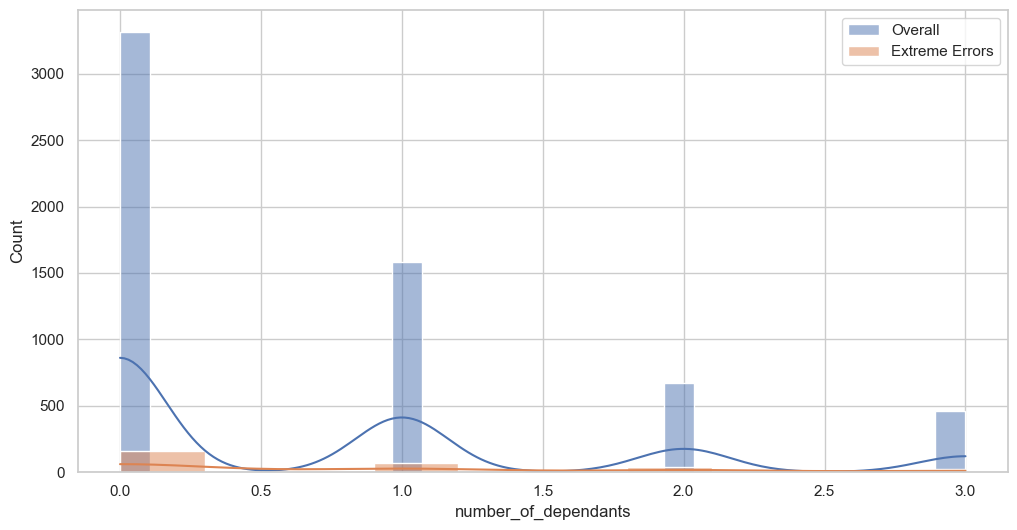

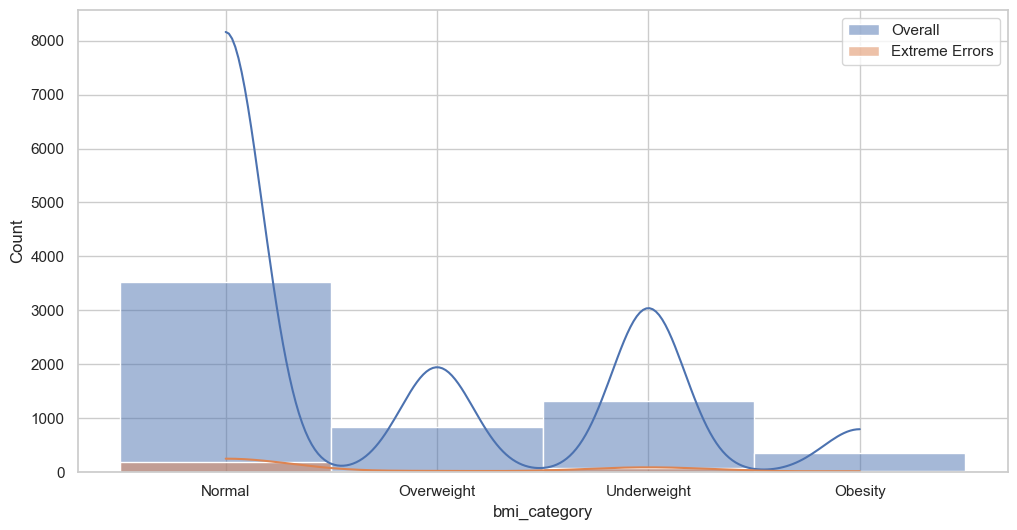

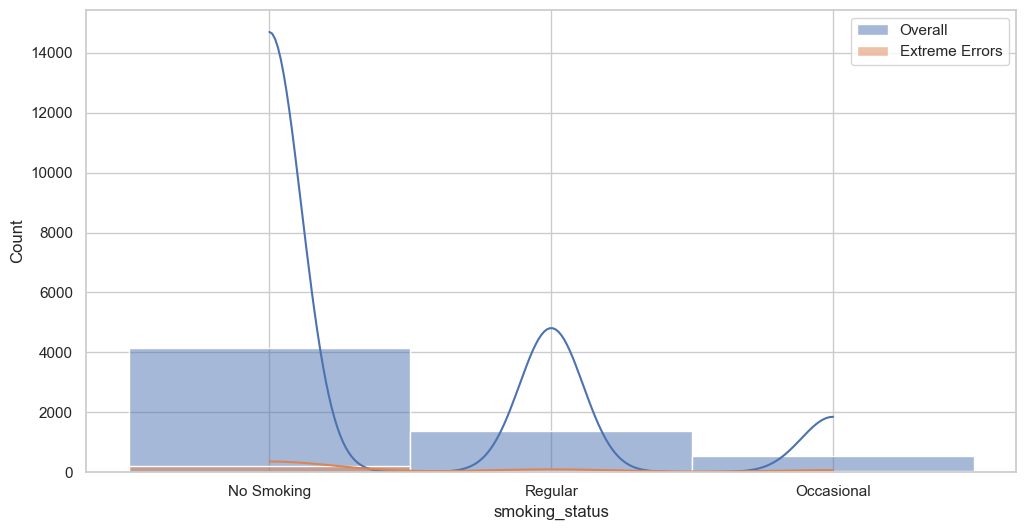

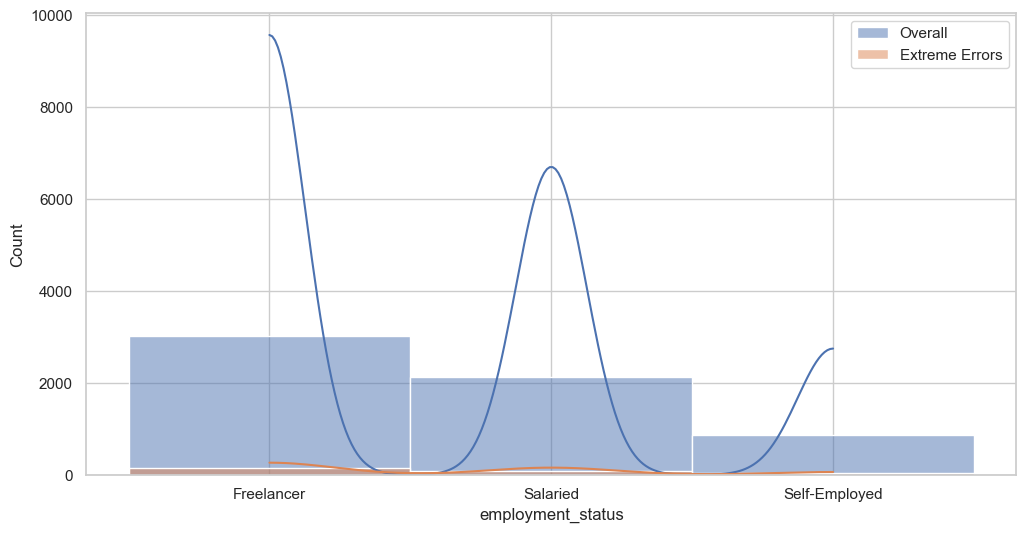

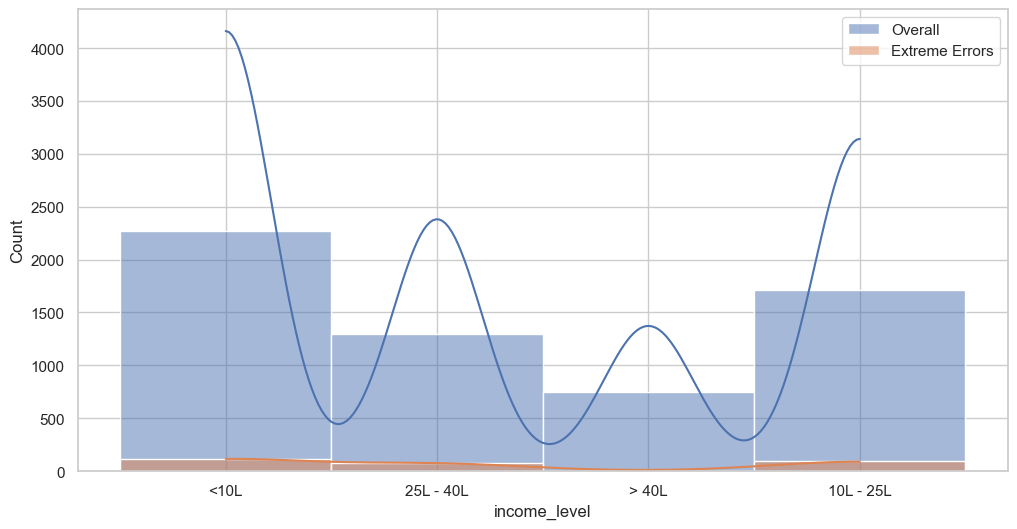

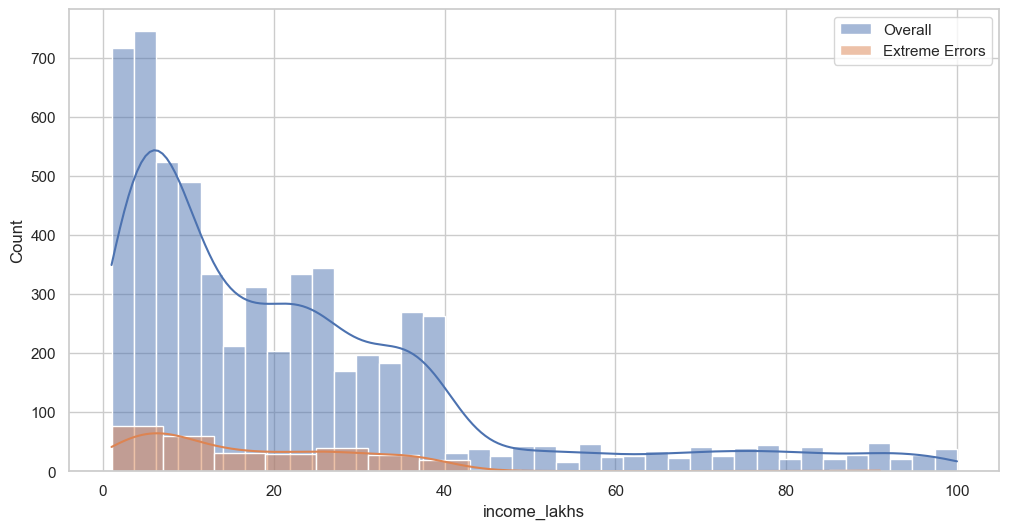

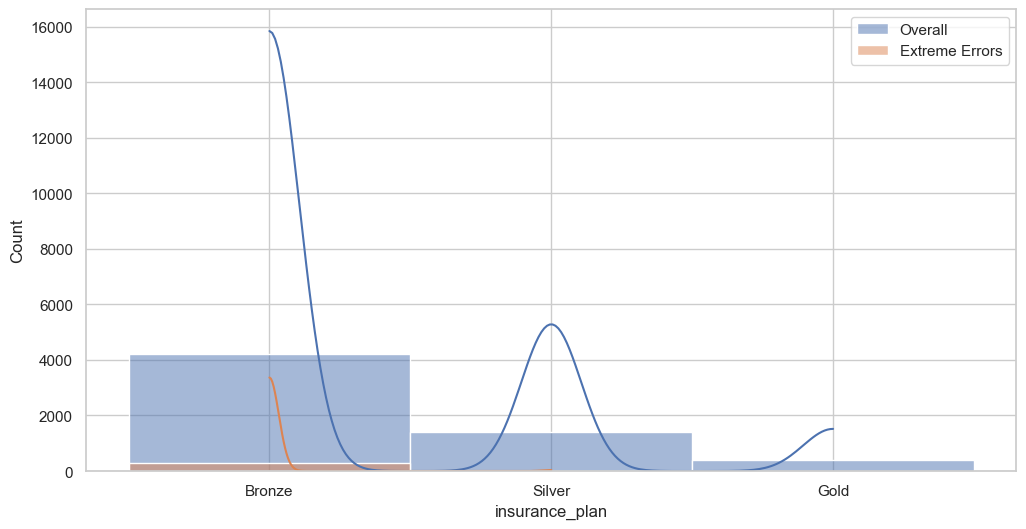

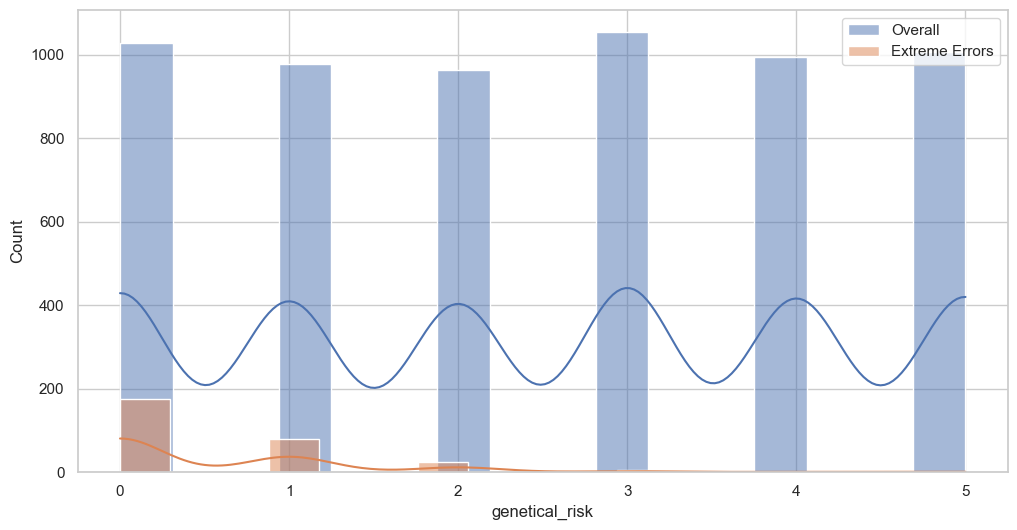

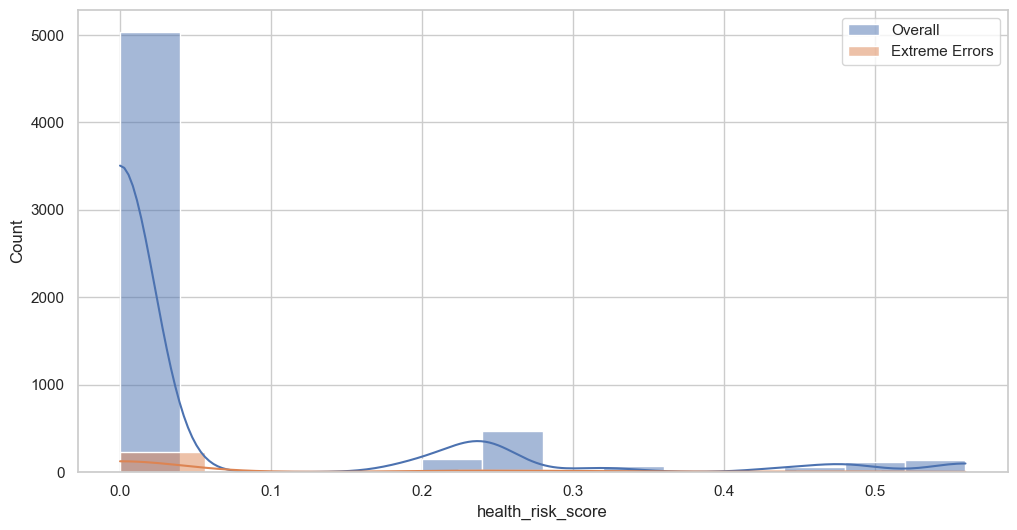

In [75]:
for feature in errors_df.columns:
    plt.figure(figsize=(12,6))
    sns.histplot(X_test[feature], label='Overall', kde=True)
    sns.histplot(errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.show()

#### __`Exporting the Trained Model`__

In [76]:
model_1

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'region',
                                                   'marital_status',
                                                   'employment_status']),
                                                 ('numerical', StandardScaler(),
                                                  ['age',
                                                   'number_of_dependants',
                                                   'income_lakhs',
                                                   'health_risk_score',
                                                   'genetical_risk']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Underweight',
                                                                                               'Normal',
                                                                                               'Overweight',
                                                                                               'Obesity'],
                                                                                              ['No '
                                                                                               'Smoking',
                                                                                               'Occasional',
                                                                                               'Regular'],
                                                                                              ['Bronze',
                                                                                               'Silver',
                                                                                               'Gold']])),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['bmi_category',
                                                   'smoking_status',
                                                   'insurance_plan'])],
                                   verbose_feature_names_out=False)),
                ('linear_regressor', LinearRegression())])

In [81]:
import joblib

joblib.dump(model_2, './artifacts/young_population_model.joblib')

['./artifacts/young_population_model.joblib']